
# **Predict the age of abalone from physical measurements**
# **Comparative Analysis of Abalone and Crab Age Prediction**


Course Code	: CSE 303
Course Title	: Statistics for Data Science
# Section                 : 2



Submitted To:
# Dr. Mohammad Manzurul Islam
Assistant Professor
Department of Computer Science & Engineering

# Submitted By:
1.	2021-3-60-101	Md Maruf Hasan
2.	2021-3-60-172 	Abdul Muhaimin Ibne Ali
3.	2022-1-60-381 	Chinmoy Karmakar


In [64]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
print("Loading Abalone Dataset...")
df_abalone = pd.read_csv("/content/drive/MyDrive/CSE 303/MiniProject/abalone.csv")

print("Loading Crab Age Prediction Dataset...")
df_crab = pd.read_csv("/content/drive/MyDrive/CSE 303/MiniProject/CrabAgePrediction.csv")

print("Datasets loaded successfully!")
print(f"Abalone dataset shape: {df_abalone.shape}")
print(f"Crab dataset shape: {df_crab.shape}")

Loading Abalone Dataset...
Loading Crab Age Prediction Dataset...
Datasets loaded successfully!
Abalone dataset shape: (4177, 9)
Crab dataset shape: (3893, 9)


In [93]:
print("ABALONE DATASET:")

print(" 1. Basic Information:")
print(df_abalone.info())

print("\n 2. First 5 rows:")
print(df_abalone.head())

print("\n 3. Dataset Description:")
print(df_abalone.describe())

print("\n 4. Column names:")
print(df_abalone.columns.tolist())

ABALONE DATASET:
 1. Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4177 non-null   object 
 1   Length         4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None

 2. First 5 rows:
  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   F   0.530     0.420   0.135       0.6770    

In [68]:
print("CRAB DATASET:")

print(" 1. Basic Information:")
print(df_crab.info())

print("\n 2. First 5 rows:")
print(df_crab.head())

print("\n 3. Dataset Description:")
print(df_crab.describe())

print("\n 4. Column names:")
print(df_crab.columns.tolist())

CRAB DATASET:
 1. Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB
None

 2. First 5 rows:
  Sex  Length  Diameter  Height     Weight  Shucked Weight  Viscera Weight  \
0   F  1.4375    1.1750  0.4125  24.635715       12.332033        5.584852   
1   M  0.8875    0.6500  0.2125   5.400580        2.296310        1.374951   
2   I  1.0375    0.7750  0.2500   7.9520

MISSING VALUES ANALYSIS: ABALONE : 
Missing values in Abalone dataset:
Sex              0
Length           0
Diameter         0
Height           0
WholeWeight      0
ShuckedWeight    0
VisceraWeight    0
ShellWeight      0
Rings            0
dtype: int64

Percentage of missing values:
Sex              0.0
Length           0.0
Diameter         0.0
Height           0.0
WholeWeight      0.0
ShuckedWeight    0.0
VisceraWeight    0.0
ShellWeight      0.0
Rings            0.0
dtype: float64


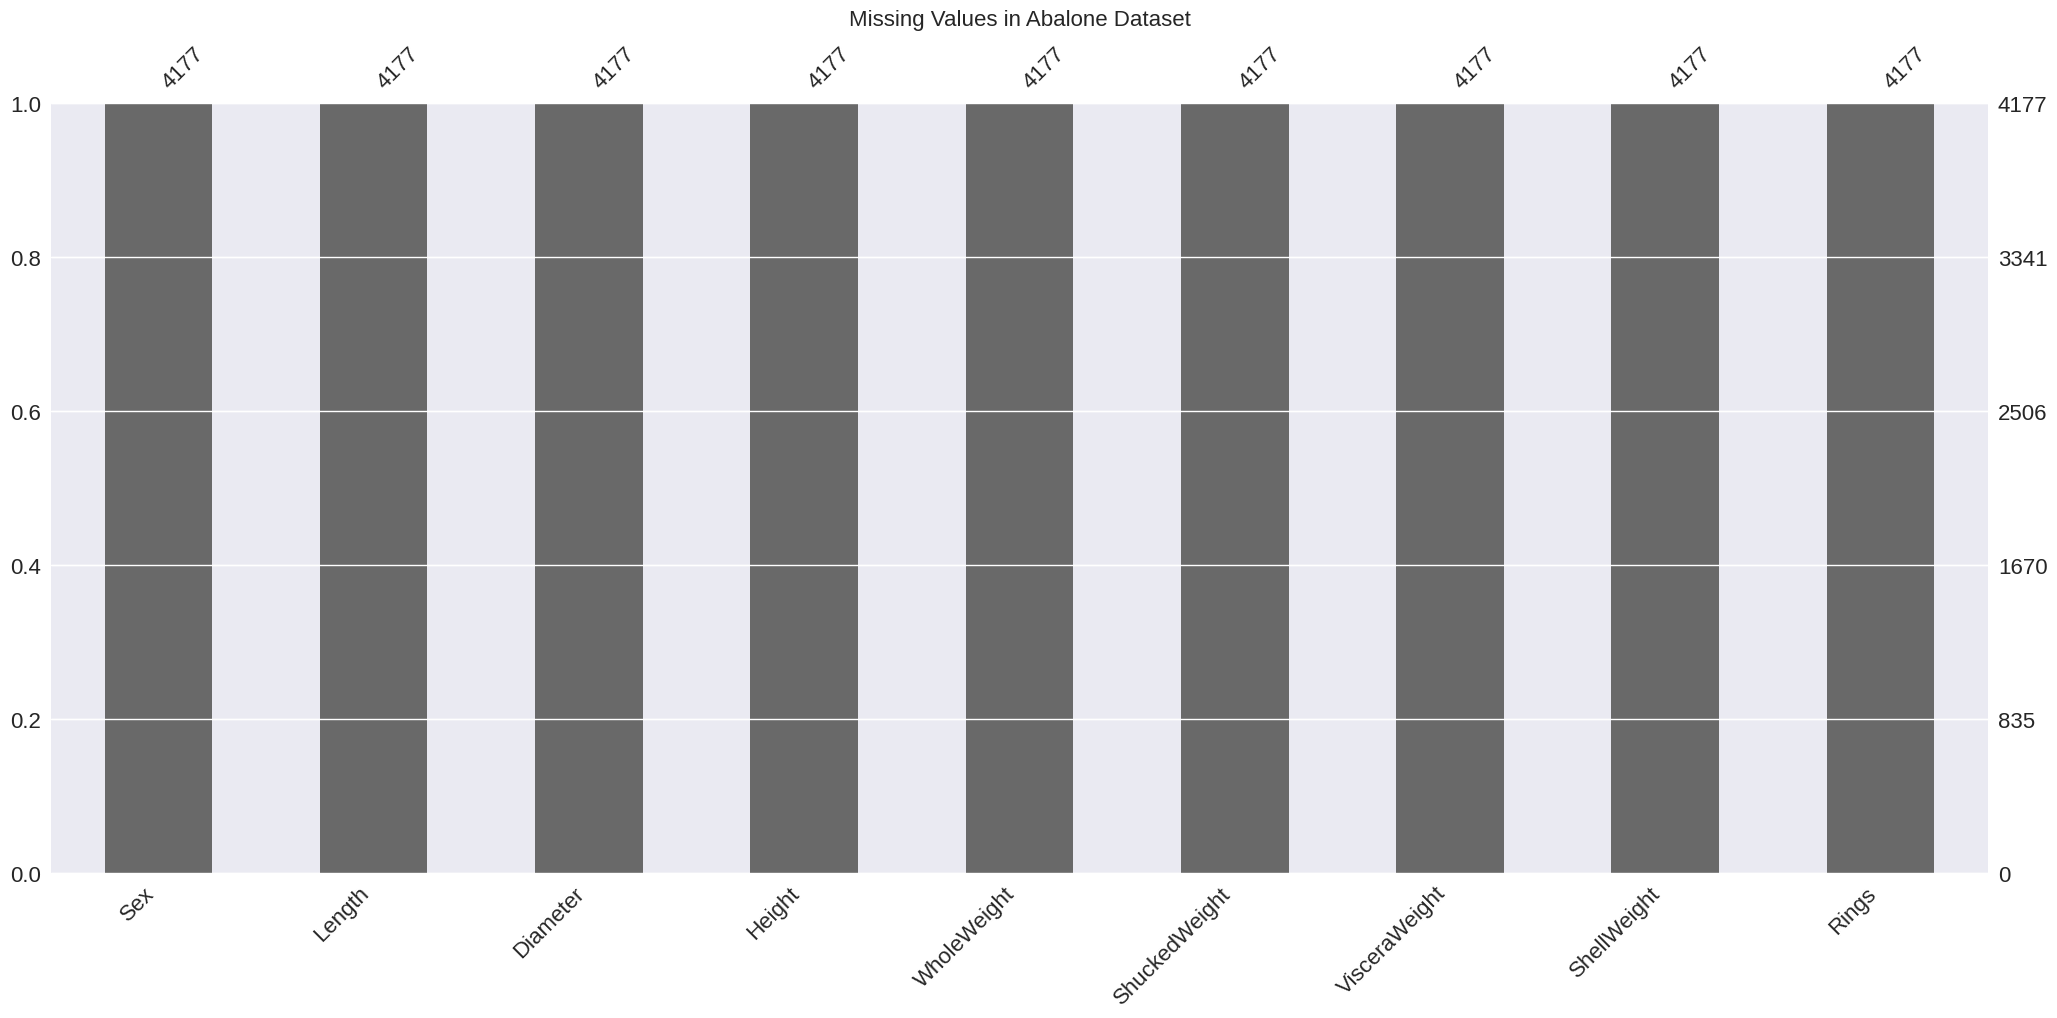

In [95]:
print("MISSING VALUES ANALYSIS: ABALONE : ")

# Check for missing values
print("Missing values in Abalone dataset:")
missing_abalone = df_abalone.isnull().sum()
print(missing_abalone)

# Percentage of missing values
missing_percentage_abalone = df_abalone.isnull().mean() * 100
print("\nPercentage of missing values:")
print(missing_percentage_abalone)

# Visualize missing values
plt.figure(figsize=(10, 5))
msno.bar(df_abalone)
plt.title('Missing Values in Abalone Dataset', size=16, pad=13)
plt.show()


MISSING VALUES ANALYSIS: CRAB :
Missing values in Crab dataset:
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64

Percentage of missing values:
Sex               0.0
Length            0.0
Diameter          0.0
Height            0.0
Weight            0.0
Shucked Weight    0.0
Viscera Weight    0.0
Shell Weight      0.0
Age               0.0
dtype: float64


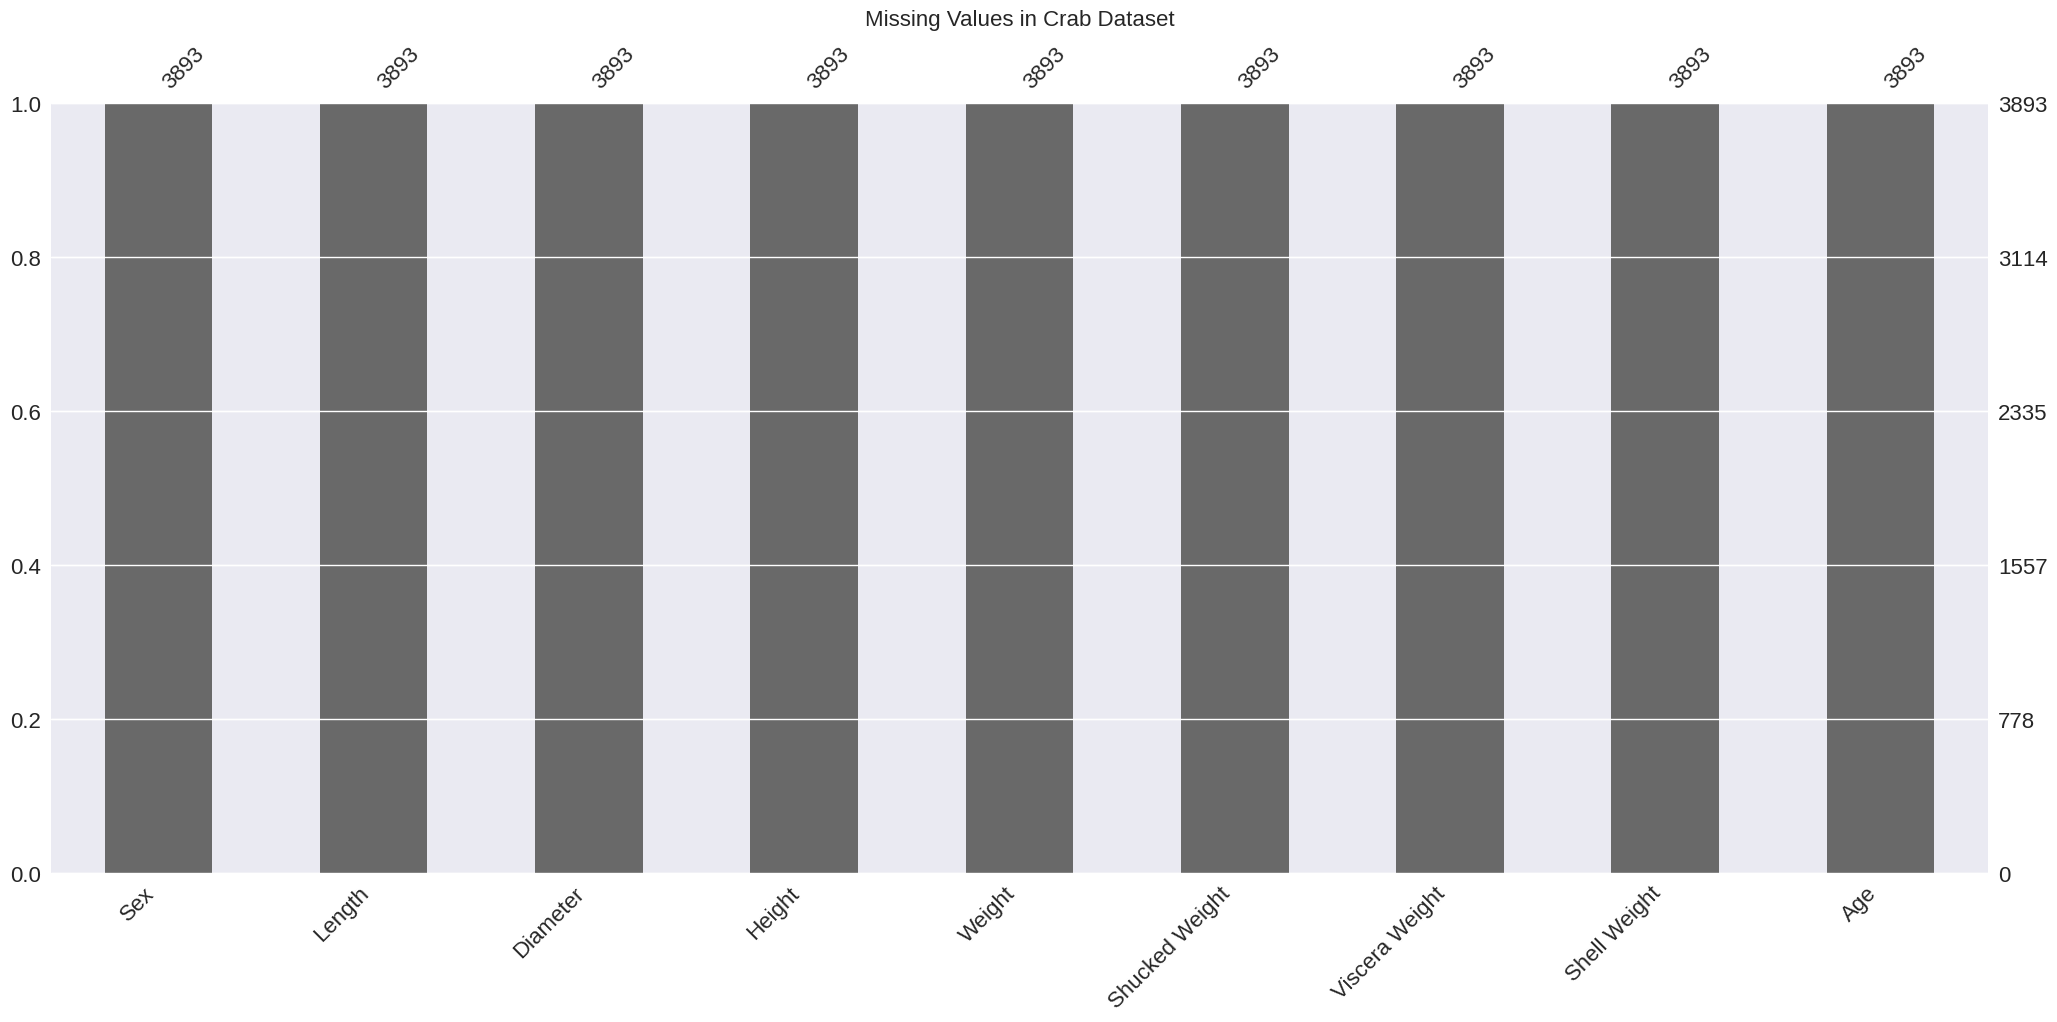

In [70]:
print("MISSING VALUES ANALYSIS: CRAB :")

# Check for missing values
print("Missing values in Crab dataset:")
missing_crab = df_crab.isnull().sum()
print(missing_crab)

# Percentage of missing values
missing_percentage_crab = df_crab.isnull().mean() * 100
print("\nPercentage of missing values:")
print(missing_percentage_crab)

# Visualize missing values
plt.figure(figsize=(12, 6))
msno.bar(df_crab)
plt.title('Missing Values in Crab Dataset', size=16, pad=13)
plt.show()

In [96]:
# Handle Missing Values: Abalone Dataset:

print("HANDLING MISSING VALUES: ABALONE :")


df_abalone_processed = df_abalone_clean.copy()

# Check if there are any missing values to handle
if df_abalone_processed.isnull().sum().sum() > 0:
    # Handle missing values based on data type
    for column in df_abalone_processed.columns:
        if df_abalone_processed[column].isnull().sum() > 0:
            if df_abalone_processed[column].dtype == 'object':
                # For categorical data, fill with mode
                mode_val = df_abalone_processed[column].mode()[0]
                df_abalone_processed[column] = df_abalone_processed[column].fillna(mode_val)
                print(f"Filled {column} missing values with mode: {mode_val}")
            else:
                # For numerical data, fill with median
                median_val = df_abalone_processed[column].median()
                df_abalone_processed[column] = df_abalone_processed[column].fillna(median_val)
                print(f"Filled {column} missing values with median: {median_val}")
else:
    print("No missing values found in Abalone dataset!")

print(f"Missing values after handling: {df_abalone_processed.isnull().sum().sum()}")

# Handle Missing Values : Crab Dataset

print("\nHANDLING MISSING VALUES: CRAB :")


df_crab_processed = df_crab_clean.copy()

# Check if there are any missing values to handle
if df_crab_processed.isnull().sum().sum() > 0:
    # Handle missing values based on data type
    for column in df_crab_processed.columns:
        if df_crab_processed[column].isnull().sum() > 0:
            if df_crab_processed[column].dtype == 'object':
                # For categorical data, fill with mode
                mode_val = df_crab_processed[column].mode()[0]
                df_crab_processed[column] = df_crab_processed[column].fillna(mode_val)
                print(f"Filled {column} missing values with mode: {mode_val}")
            else:
                # For numerical data, fill with median
                median_val = df_crab_processed[column].median()
                df_crab_processed[column] = df_crab_processed[column].fillna(median_val)
                print(f"Filled {column} missing values with median: {median_val}")
else:
    print("No missing values found in Crab dataset!")

print(f"Missing values after handling: {df_crab_processed.isnull().sum().sum()}")

HANDLING MISSING VALUES: ABALONE :
No missing values found in Abalone dataset!
Missing values after handling: 0

HANDLING MISSING VALUES: CRAB :
No missing values found in Crab dataset!
Missing values after handling: 0


In [106]:
print("OUTLIER DETECTION: ABALONE")

def find_outliers_IQR(df_column):
    q1 = df_column.quantile(0.25)
    q3 = df_column.quantile(0.75)
    IQR = q3 - q1
    outliers = df_column[((df_column < (q1 - 1.5 * IQR)) | (df_column > (q3 + 1.5 * IQR)))]
    return outliers

# Check outliers in key numeric columns
for column in numeric_features[:3]:  # Check first 3 numeric features
    outliers = find_outliers_IQR(df_abalone_processed[column])
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"Max outlier value: {outliers.max()}")
        print(f"Min outlier value: {outliers.min()}")

OUTLIER DETECTION: ABALONE

Outliers in Length:
Number of outliers: 49
Max outlier value: 0.2
Min outlier value: 0.075

Outliers in Diameter:
Number of outliers: 59
Max outlier value: 0.15
Min outlier value: 0.055

Outliers in Height:
Number of outliers: 29
Max outlier value: 1.13
Min outlier value: 0.0


In [82]:
print("OUTLIER DETECTION: CRAB")

# Check outliers in key numeric columns
for column in numeric_features_crab[:3]:  # Check first 3 numeric features
    outliers = find_outliers_IQR(df_crab_processed[column])
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"Max outlier value: {outliers.max()}")
        print(f"Min outlier value: {outliers.min()}")

OUTLIER DETECTION: CRAB

Outliers in Length:
Number of outliers: 45
Max outlier value: 0.5
Min outlier value: 0.1875

Outliers in Diameter:
Number of outliers: 58
Max outlier value: 0.3875
Min outlier value: 0.1375

Outliers in Height:
Number of outliers: 27
Max outlier value: 2.825
Min outlier value: 0.0


In [107]:
print("DUPLICATE VALUES ANALYSIS:")

# Check duplicates in Abalone dataset
abalone_duplicates = df_abalone.duplicated().sum()
print(f"Number of duplicate rows in Abalone dataset: {abalone_duplicates}")

# Check duplicates in Crab dataset
crab_duplicates = df_crab.duplicated().sum()
print(f"Number of duplicate rows in Crab dataset: {crab_duplicates}")

# Remove duplicates if any
df_abalone_clean = df_abalone.drop_duplicates()
df_crab_clean = df_crab.drop_duplicates()

print(f"\nAbalone dataset shape after removing duplicates: {df_abalone_clean.shape}")
print(f"Crab dataset shape after removing duplicates: {df_crab_clean.shape}")


DUPLICATE VALUES ANALYSIS:
Number of duplicate rows in Abalone dataset: 0
Number of duplicate rows in Crab dataset: 0

Abalone dataset shape after removing duplicates: (4177, 9)
Crab dataset shape after removing duplicates: (3893, 9)


In [98]:
print("CATEGORICAL VARIABLE CONVERSION: ABALONE :")

# Check for categorical variables
print("Data types in Abalone dataset:")
print(df_abalone_clean.dtypes)

# Convert Sex column if it exists
if 'Sex' in df_abalone_clean.columns:
    print(f"\nUnique values in Sex column: {df_abalone_clean['Sex'].unique()}")

    # Map Sex values to numerical
    sex_mapping = {'M': 0, 'F': 1, 'I': 2}  # M=Male, F=Female, I=Infant
    df_abalone_processed['Sex_Numeric'] = df_abalone_clean['Sex'].map(sex_mapping)

    print("Sex column converted to numeric:")
    print(df_abalone_processed[['Sex', 'Sex_Numeric']].head())

# Check for other categorical columns
categorical_cols = df_abalone_clean.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {categorical_cols.tolist()}")

CATEGORICAL VARIABLE CONVERSION: ABALONE :
Data types in Abalone dataset:
Sex               object
Length           float64
Diameter         float64
Height           float64
WholeWeight      float64
ShuckedWeight    float64
VisceraWeight    float64
ShellWeight      float64
Rings              int64
dtype: object

Unique values in Sex column: ['M' 'F' 'I']
Sex column converted to numeric:
  Sex  Sex_Numeric
0   M            0
1   M            0
2   F            1
3   M            0
4   I            2

Categorical columns: ['Sex']


In [99]:
print("CATEGORICAL VARIABLE CONVERSION: CRAB: ")
print("="*50)

# Check for categorical variables
print("Data types in Crab dataset:")
print(df_crab_clean.dtypes)

# Convert any categorical variables to numeric
categorical_cols_crab = df_crab_clean.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols_crab.tolist()}")

if len(categorical_cols_crab) > 0:
    for col in categorical_cols_crab:
        print(f"\nUnique values in {col}: {df_crab_clean[col].unique()}")

        # Use label encoding for categorical variables
        unique_vals = df_crab_clean[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        df_crab_processed[f'{col}_Numeric'] = df_crab_clean[col].map(mapping)

        print(f"Mapping for {col}: {mapping}")

CATEGORICAL VARIABLE CONVERSION: CRAB: 
Data types in Crab dataset:
Sex                object
Length            float64
Diameter          float64
Height            float64
Weight            float64
Shucked Weight    float64
Viscera Weight    float64
Shell Weight      float64
Age                 int64
dtype: object
Categorical columns: ['Sex']

Unique values in Sex: ['F' 'M' 'I']
Mapping for Sex: {'F': 0, 'M': 1, 'I': 2}


CORRELATION ANALYSIS: ABALONE :
Correlation Matrix: Abalone:


,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings,Sex_Numeric
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720,-0.448765
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660,-0.458245
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467,-0.417928
WholeWeight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390,-0.461238
ShuckedWeight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884,-0.440927
VisceraWeight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819,-0.454658
ShellWeight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574,-0.445549
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,-0.351822
Sex_Numeric,-0.448765,-0.458245,-0.417928,-0.461238,-0.440927,-0.454658,-0.445549,-0.351822,1.000000


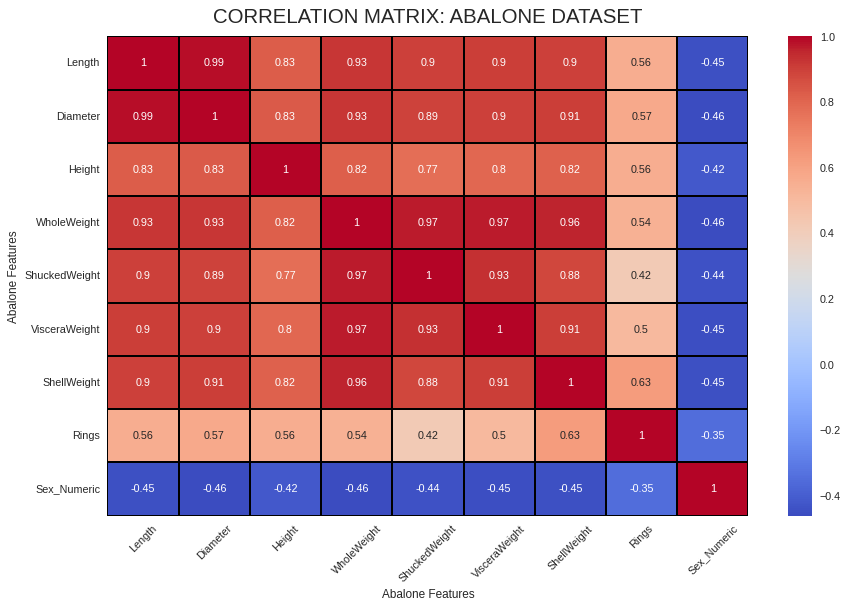

In [100]:
print("CORRELATION ANALYSIS: ABALONE :")

# Select only numeric columns for correlation
numeric_cols_abalone = df_abalone_processed.select_dtypes(include=[np.number]).columns
df_abalone_numeric = df_abalone_processed[numeric_cols_abalone]

# Calculate correlation matrix
correlation_abalone = df_abalone_numeric.corr()
print("Correlation Matrix: Abalone:")
display(correlation_abalone)

# Visualize correlation matrix
plt.figure(figsize=(12, 8), dpi=77)
sns.heatmap(correlation_abalone, linecolor='black', linewidths=0.1, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Abalone Dataset'.upper(), size=19, pad=13)
plt.xlabel('Abalone Features')
plt.ylabel('Abalone Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap shows the correlation matrix for the numerical features in the Abalone dataset. Darker red indicates strong positive correlation, and darker blue indicates strong negative correlation. We can observe strong positive correlations among most physical measurements (Length, Diameter, etc.) and moderate positive correlation between these features and 'Rings' (Age).

CORRELATION ANALYSIS: CRAB :
Correlation Matrix: Crab:


,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Sex_Numeric
Length,1.000000,0.986653,0.823081,0.925374,0.898181,0.903253,0.897736,0.554973,-0.501807
Diameter,0.986653,1.000000,0.829532,0.925770,0.893626,0.899810,0.905561,0.573844,-0.515211
Height,0.823081,0.829532,1.000000,0.814405,0.770961,0.793272,0.812290,0.551956,-0.473092
Weight,0.925374,0.925770,0.814405,1.000000,0.969077,0.965583,0.955269,0.538819,-0.498866
Shucked Weight,0.898181,0.893626,0.770961,0.969077,1.000000,0.931280,0.882406,0.418760,-0.456450
Viscera Weight,0.903253,0.899810,0.793272,0.965583,0.931280,1.000000,0.906105,0.501328,-0.503100
Shell Weight,0.897736,0.905561,0.812290,0.955269,0.882406,0.906105,1.000000,0.625195,-0.497959
Age,0.554973,0.573844,0.551956,0.538819,0.418760,0.501328,0.625195,1.000000,-0.402077
Sex_Numeric,-0.501807,-0.515211,-0.473092,-0.498866,-0.456450,-0.503100,-0.497959,-0.402077,1.000000


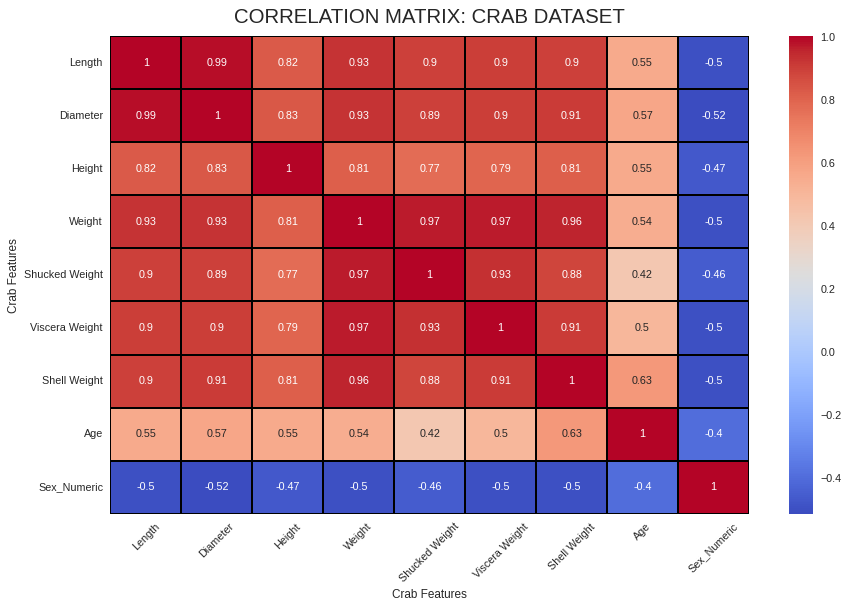

In [101]:
print("CORRELATION ANALYSIS: CRAB :")

# Select only numeric columns for correlation
numeric_cols_crab = df_crab_processed.select_dtypes(include=[np.number]).columns
df_crab_numeric = df_crab_processed[numeric_cols_crab]

# Calculate correlation matrix
correlation_crab = df_crab_numeric.corr()
print("Correlation Matrix: Crab:")
display(correlation_crab)

# Visualize correlation matrix
plt.figure(figsize=(12, 8), dpi=77)
sns.heatmap(correlation_crab, linecolor='Black', linewidths=0.1, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Crab Dataset'.upper(), size=19, pad=13)
plt.xlabel('Crab Features')
plt.ylabel('Crab Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap shows the correlation matrix for the numerical features in the Crab dataset. Similar to the Abalone dataset, there are strong positive correlations among the physical and weight measurements. 'Shell Weight' shows the highest positive correlation with 'Age'.

DATA VISUALIZATION: ABALONE:


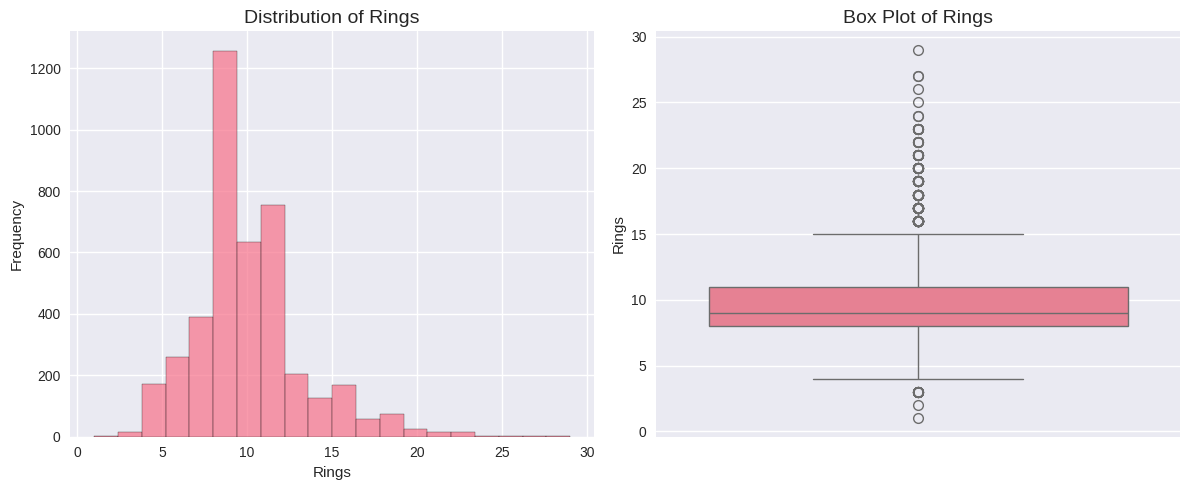

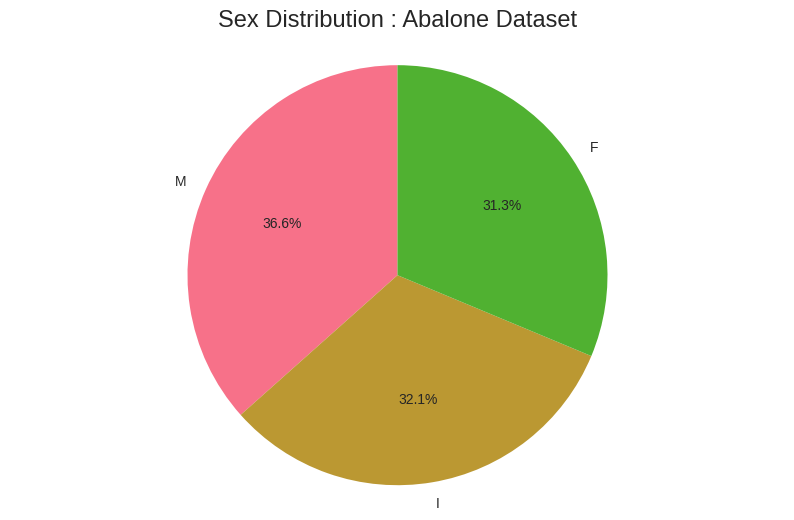

In [103]:
print("DATA VISUALIZATION: ABALONE:")


# Identify target variable (likely 'Rings' for age prediction)
target_col_abalone = 'Rings' if 'Rings' in df_abalone_processed.columns else df_abalone_processed.columns[-1]

# 1. Distribution of target variable
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_abalone_processed[target_col_abalone], bins=20, edgecolor='black', alpha=0.7)
plt.title(f'Distribution of {target_col_abalone}', size=14)
plt.xlabel(target_col_abalone)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_abalone_processed[target_col_abalone])
plt.title(f'Box Plot of {target_col_abalone}', size=14)
plt.tight_layout()
plt.show()

# 2. Sex distribution (if exists)
if 'Sex' in df_abalone_processed.columns:
    sex_counts = df_abalone_processed['Sex'].value_counts()
    plt.figure(figsize=(10, 6))
    plt.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Sex Distribution : Abalone Dataset', size=17, pad=13)
    plt.axis('equal')
    plt.show()



**Interpretation:** These plots show the distribution of 'Rings' (Age) in the Abalone dataset. The histogram indicates that the majority of abalones in this dataset are younger, with the distribution skewed towards lower ring counts. The box plot shows the median age and highlights the presence of outliers with a higher number of rings.

Show


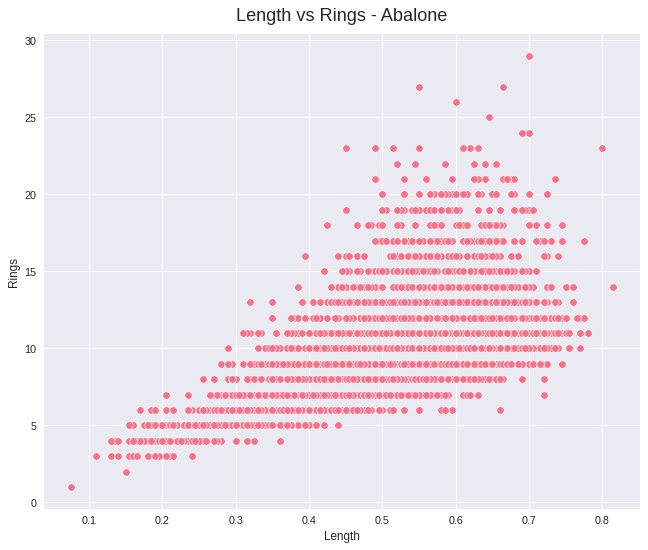

In [138]:
# Scatter plot - Abalone Length vs Rings
plt.figure(figsize=(10,8), dpi=77)
sns.scatterplot(x=df_abalone_processed['Length'], y=df_abalone_processed[target_col_abalone])
plt.title(f'Length vs {target_col_abalone} - Abalone', size=17, pad=13)
plt.xlabel('Length')
plt.ylabel(target_col_abalone)
plt.show()

**Interpretation: Scatter plot - Abalone Length vs Rings**

This scatter plot shows the relationship between 'Length' and 'Rings' (Age) in the Abalone dataset. We can observe a general positive trend, indicating that as the length of the abalone increases, the number of rings (and thus age) also tends to increase. However, the points are quite scattered, especially for higher lengths/ages, suggesting that length alone is not a perfect predictor of age and there is variability in age for abalones of the same length.

ADDITIONAL VISUALIZATIONS: ABALONE


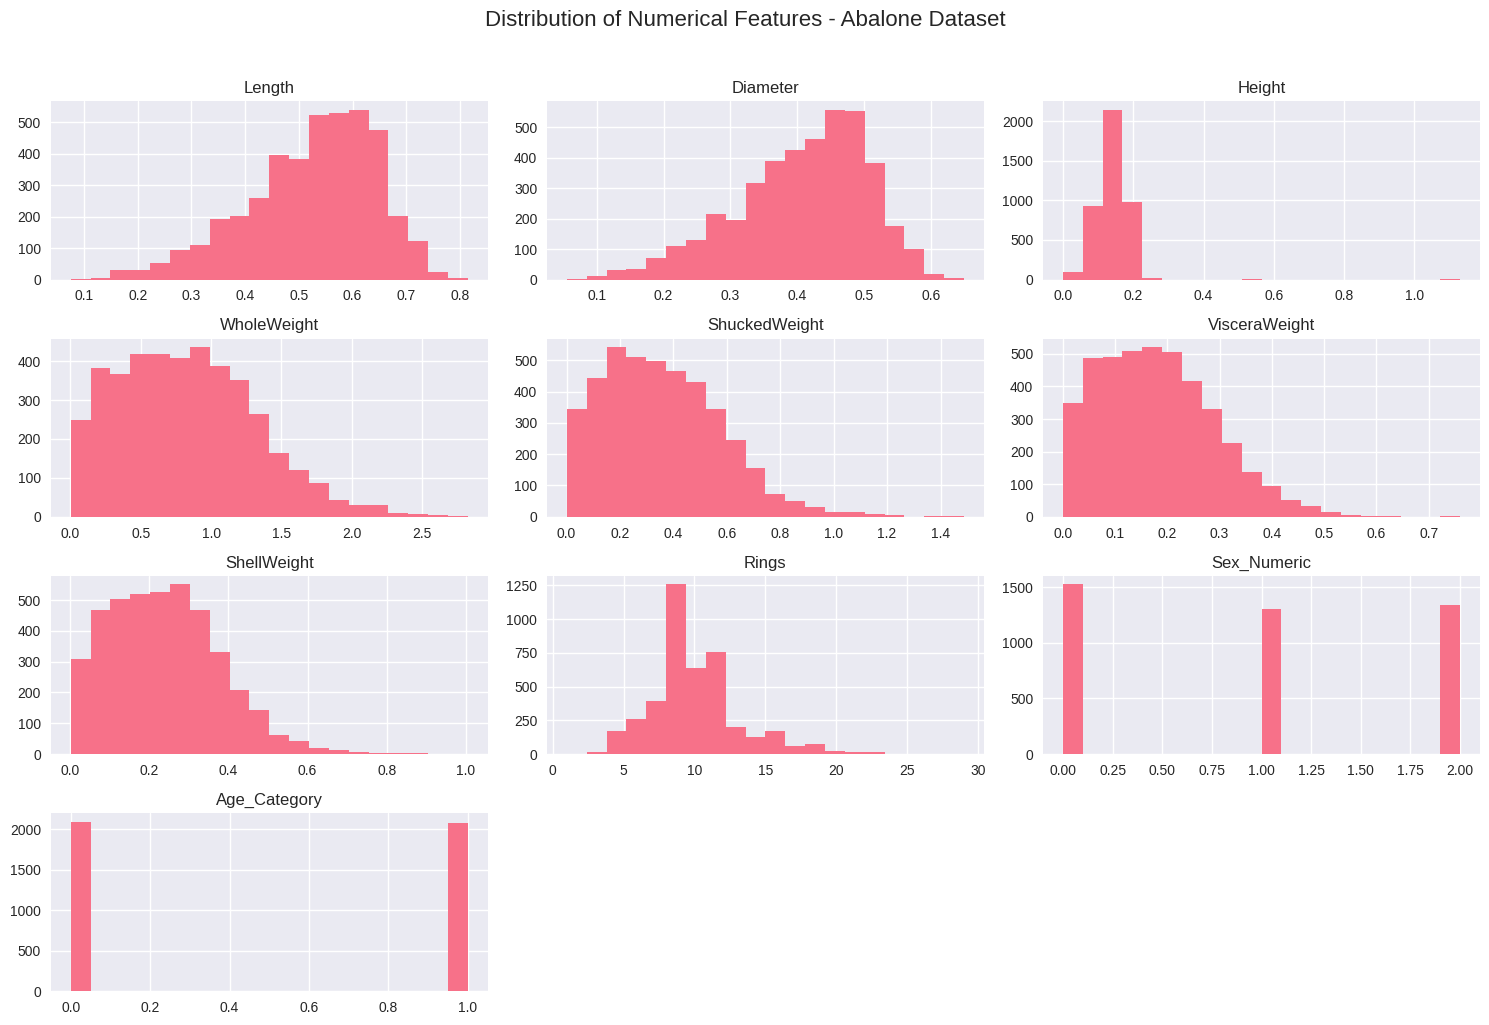

In [140]:
print("ADDITIONAL VISUALIZATIONS: ABALONE")

# Distribution of numerical features
df_abalone_processed.hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features - Abalone Dataset", y=1.02, size=16)
plt.tight_layout()
plt.show()



DATA VISUALIZATION : CRAB:


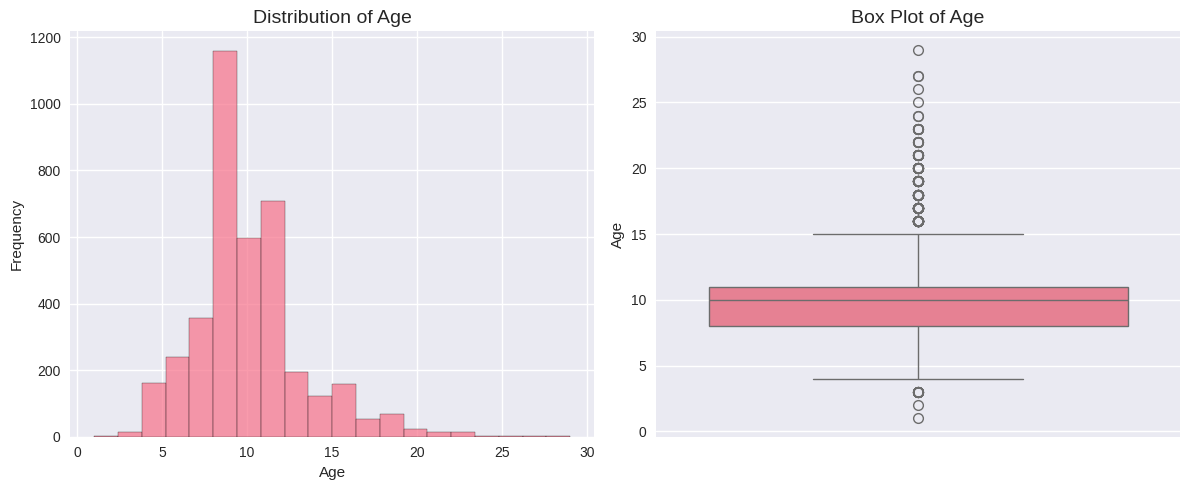

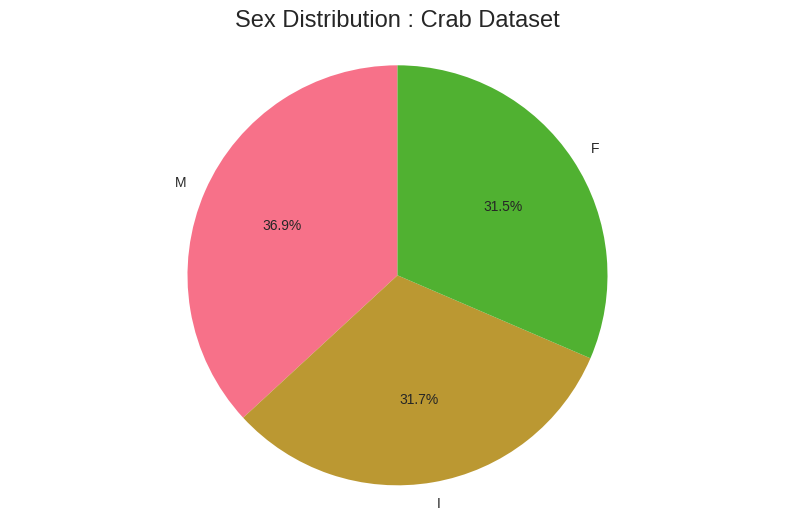

In [104]:
print("DATA VISUALIZATION : CRAB:")

# Identify target variable (likely 'Age' for age prediction)
target_col_crab = 'Age' if 'Age' in df_crab_processed.columns else df_crab_processed.columns[-1]

# 1. Distribution of target variable
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_crab_processed[target_col_crab], bins=20, edgecolor='black', alpha=0.7)
plt.title(f'Distribution of {target_col_crab}', size=14)
plt.xlabel(target_col_crab)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_crab_processed[target_col_crab])
plt.title(f'Box Plot of {target_col_crab}', size=14)
plt.tight_layout()
plt.show()


# 2. Sex distribution (if exists)
if 'Sex' in df_crab_processed.columns:
    sex_counts = df_crab_processed['Sex'].value_counts()
    plt.figure(figsize=(10, 6))
    plt.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Sex Distribution : Crab Dataset', size=17, pad=13)
    plt.axis('equal')
    plt.show()


**Interpretation:** These plots show the distribution of 'Age' in the Crab dataset. Similar to the Abalone dataset, the age distribution is skewed towards younger crabs, with fewer older individuals. The box plot also reveals outliers in the higher age ranges.

Show


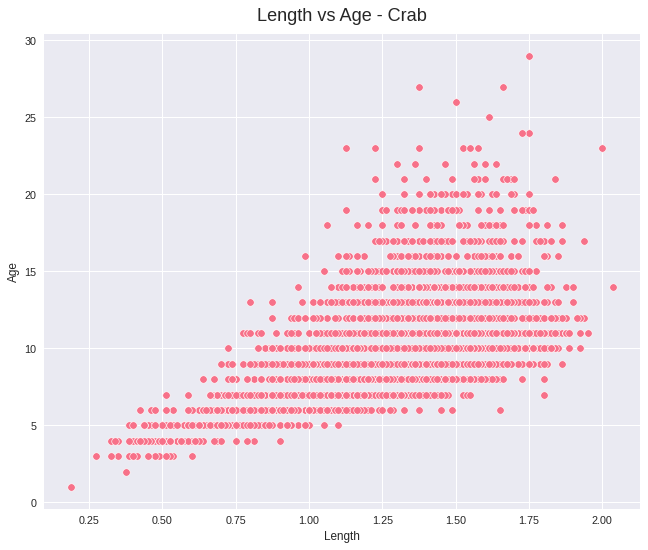

In [141]:
# Scatter plot - Crab Length vs Age
plt.figure(figsize=(10,8), dpi=77)
sns.scatterplot(x=df_crab_processed['Length'], y=df_crab_processed[target_col_crab])
plt.title(f'Length vs {target_col_crab} - Crab', size=17, pad=13)
plt.xlabel('Length')
plt.ylabel(target_col_crab)
plt.show()

**Interpretation: Scatter plot - Crab Length vs Age**

This scatter plot visualizes the relationship between 'Length' and 'Age' in the Crab dataset. Similar to the Abalone dataset, there is a clear positive correlation between length and age. As the length of the crab increases, its age generally increases as well. The spread of the data points also suggests that length is a good indicator but not a sole determinant of age, with variations in age occurring among crabs of similar lengths.

ADDITIONAL VISUALIZATIONS: CRAB


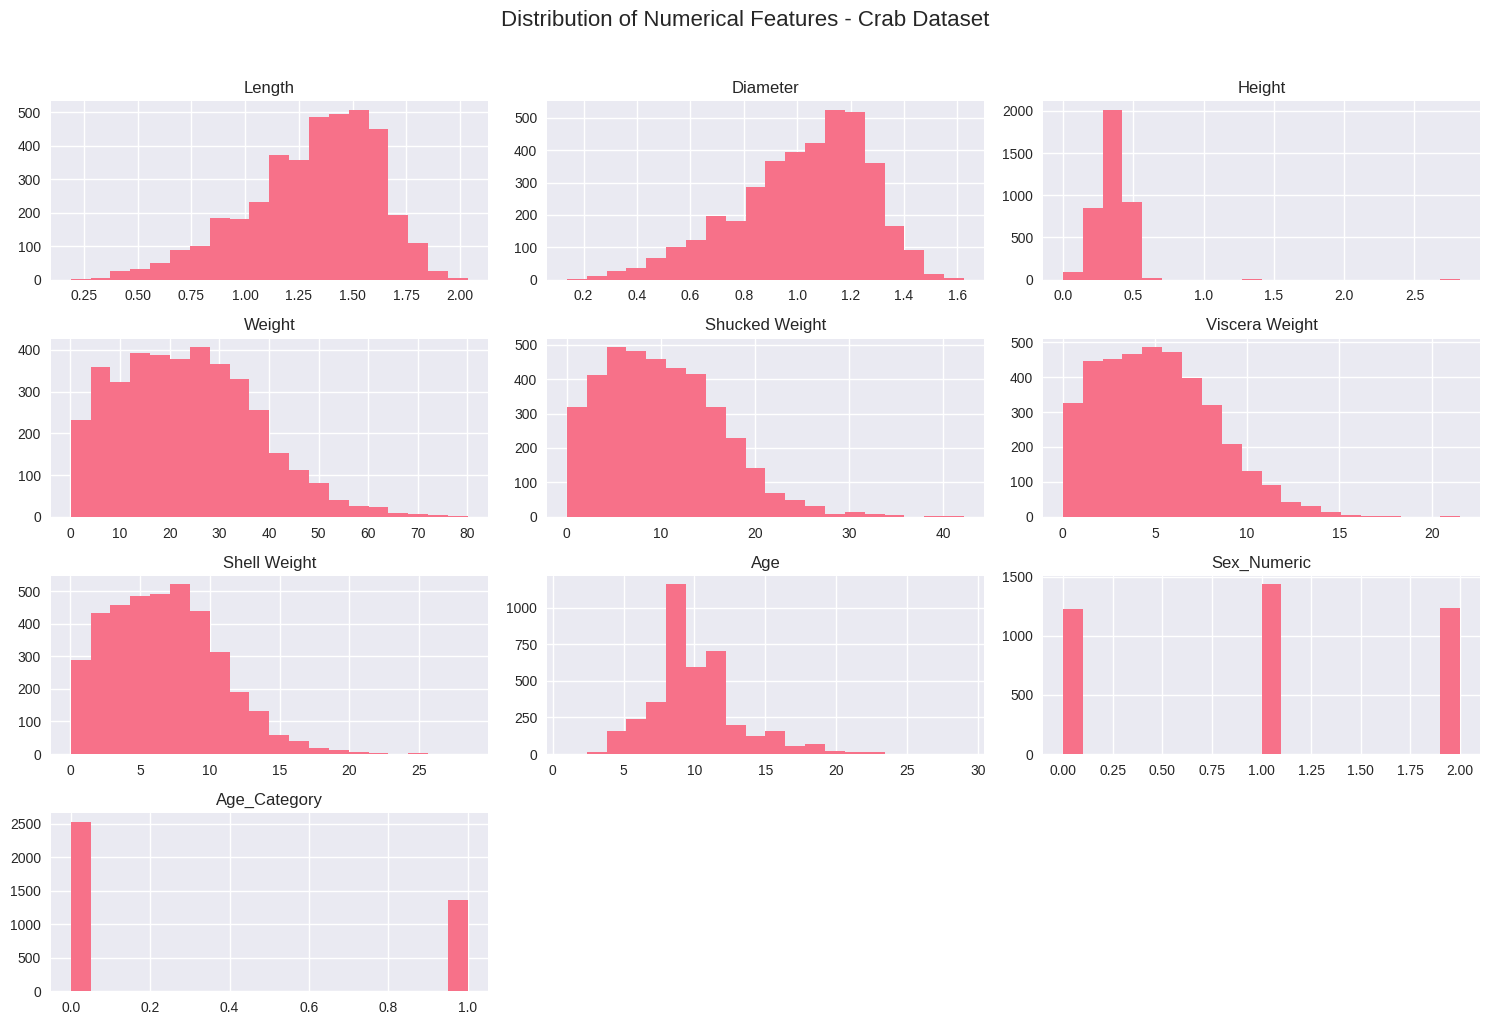

In [142]:
print("ADDITIONAL VISUALIZATIONS: CRAB")

# Distribution of numerical features
df_crab_processed.hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features - Crab Dataset", y=1.02, size=16)
plt.tight_layout()
plt.show()


In [108]:
print("PREPARING DATA FOR ML: ABALONE:")

# Create final dataset for ML
df_abalone_final = df_abalone_processed.copy()

# Select features and target
X_abalone = df_abalone_final.select_dtypes(include=[np.number]).drop(columns=[target_col_abalone])
y_abalone = df_abalone_final[target_col_abalone]

print(f"Features shape: {X_abalone.shape}")
print(f"Target shape: {y_abalone.shape}")
print(f"Feature columns: {X_abalone.columns.tolist()}")

# Split the data
X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X_abalone, y_abalone, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train_ab.shape}")
print(f"Testing set shape: {X_test_ab.shape}")

PREPARING DATA FOR ML: ABALONE:
Features shape: (4177, 8)
Target shape: (4177,)
Feature columns: ['Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Sex_Numeric']
Training set shape: (3341, 8)
Testing set shape: (836, 8)


In [109]:
print("PREPARING DATA FOR ML - CRAB")
print("="*50)

# Create final dataset for ML
df_crab_final = df_crab_processed.copy()

# Select features and target
X_crab = df_crab_final.select_dtypes(include=[np.number]).drop(columns=[target_col_crab])
y_crab = df_crab_final[target_col_crab]

print(f"Features shape: {X_crab.shape}")
print(f"Target shape: {y_crab.shape}")
print(f"Feature columns: {X_crab.columns.tolist()}")

# Split the data
X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(
    X_crab, y_crab, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train_cr.shape}")
print(f"Testing set shape: {X_test_cr.shape}")

PREPARING DATA FOR ML - CRAB
Features shape: (3893, 8)
Target shape: (3893,)
Feature columns: ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight', 'Sex_Numeric']
Training set shape: (3114, 8)
Testing set shape: (779, 8)


LINEAR REGRESSION: ABALONE DATASET :
Linear Regression Results: Abalone :
MAE: 1.6068
MSE: 4.9503
RMSE: 2.2249
R² Score: 0.5427


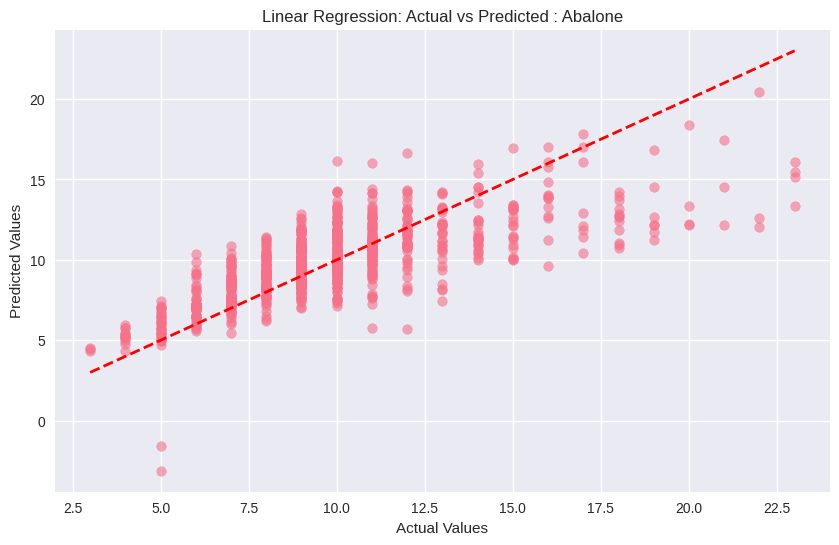

In [110]:
print("LINEAR REGRESSION: ABALONE DATASET :")

# Initialize and train Linear Regression model
lr_abalone = LinearRegression()
lr_abalone.fit(X_train_ab, y_train_ab)

# Make predictions
y_pred_lr_ab = lr_abalone.predict(X_test_ab)

# Calculate evaluation metrics
lr_mae_ab = mean_absolute_error(y_test_ab, y_pred_lr_ab)
lr_mse_ab = mean_squared_error(y_test_ab, y_pred_lr_ab)
lr_rmse_ab = np.sqrt(lr_mse_ab)

print("Linear Regression Results: Abalone :")
print(f"MAE: {lr_mae_ab:.4f}")
print(f"MSE: {lr_mse_ab:.4f}")
print(f"RMSE: {lr_rmse_ab:.4f}")
print(f"R² Score: {lr_abalone.score(X_test_ab, y_test_ab):.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_ab, y_pred_lr_ab, alpha=0.6)
plt.plot([y_test_ab.min(), y_test_ab.max()], [y_test_ab.min(), y_test_ab.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted : Abalone')
plt.show()

**Interpretation of Linear Regression Results (Abalone):**

*   **MAE (Mean Absolute Error):** This metric represents the average absolute difference between the actual 'Rings' values and the predicted 'Rings' values. An MAE of 1.6068 means that, on average, our Linear Regression model's predictions for abalone rings are off by about 1.61 rings.
*   **MSE (Mean Squared Error):** This metric calculates the average of the squared differences between actual and predicted values. It penalizes larger errors more heavily than MAE. An MSE of 4.9503 means the average squared error is about 4.95.
*   **RMSE (Root Mean Squared Error):** This is the square root of the MSE and is on the same scale as the target variable ('Rings'). An RMSE of 2.2249 means that the typical error in our predictions is around 2.22 rings.
*   **R² Score:** This metric indicates the proportion of the variance in the target variable ('Rings') that is predictable from the features. An R² score of 0.5427 means that approximately 54.27% of the variation in abalone rings can be explained by the features in the model. A higher R² score indicates a better fit.

LINEAR REGRESSION: CRAB DATASET: 
Linear Regression Results Crab:
MAE: 1.5186
MSE: 4.6487
RMSE: 2.1561
R² Score: 0.5162


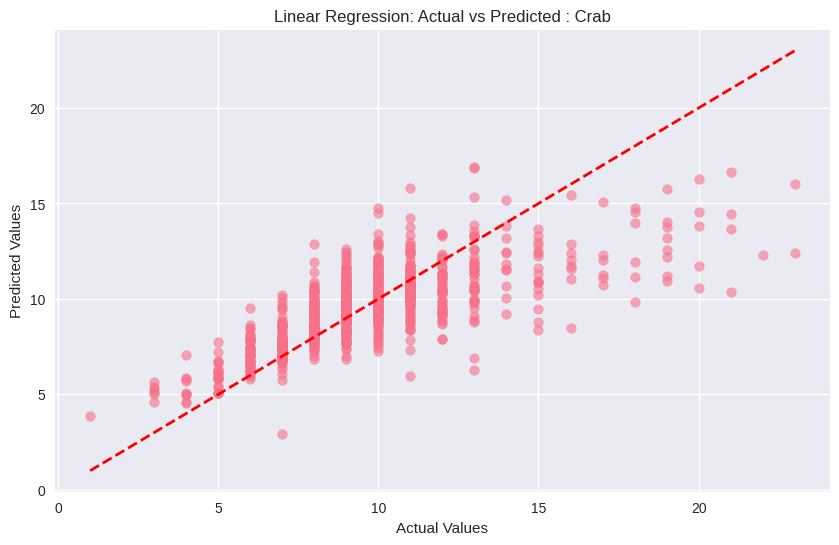

In [111]:
print("LINEAR REGRESSION: CRAB DATASET: ")

# Initialize and train Linear Regression model
lr_crab = LinearRegression()
lr_crab.fit(X_train_cr, y_train_cr)

# Make predictions
y_pred_lr_cr = lr_crab.predict(X_test_cr)

# Calculate evaluation metrics
lr_mae_cr = mean_absolute_error(y_test_cr, y_pred_lr_cr)
lr_mse_cr = mean_squared_error(y_test_cr, y_pred_lr_cr)
lr_rmse_cr = np.sqrt(lr_mse_cr)

print("Linear Regression Results Crab:")
print(f"MAE: {lr_mae_cr:.4f}")
print(f"MSE: {lr_mse_cr:.4f}")
print(f"RMSE: {lr_rmse_cr:.4f}")
print(f"R² Score: {lr_crab.score(X_test_cr, y_test_cr):.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_cr, y_pred_lr_cr, alpha=0.6)
plt.plot([y_test_cr.min(), y_test_cr.max()], [y_test_cr.min(), y_test_cr.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted : Crab')
plt.show()

**Interpretation of Linear Regression Results (Crab):**

*   **MAE (Mean Absolute Error):** The average absolute difference between actual and predicted 'Age' values is 1.5186. This means the Linear Regression model's age predictions for crabs are, on average, off by about 1.52 years.
*   **MSE (Mean Squared Error):** The average squared error in the crab age predictions is 4.6487.
*   **RMSE (Root Mean Squared Error):** The typical error in the crab age predictions is around 2.1561 years.
*   **R² Score:** An R² score of 0.5162 indicates that approximately 51.62% of the variation in crab age can be explained by the features in the model.

Comparing the Linear Regression results for both datasets, the performance is quite similar, with slightly lower error metrics (MAE, MSE, RMSE) and a slightly lower R² score for the Crab dataset.

In [112]:
print("CREATE BINARY CLASSIFICATION : ABALONE")

# Create binary target for logistic regression (Young vs Old based on median)
median_age = df_abalone_processed[target_col_abalone].median()
print(f"Median {target_col_abalone}: {median_age}")

# Creating a new column with binary classification: 1 for above median (old), 0 for below median (young)
df_abalone_processed['Age_Category'] = np.where((df_abalone_processed[target_col_abalone] > median_age), 1, 0)

# Checking if the column has been added
print("Age category distribution:")
print(df_abalone_processed['Age_Category'].value_counts())
print("\nDataset with new column:")
print(df_abalone_processed.head())

CREATE BINARY CLASSIFICATION : ABALONE
Median Rings: 9.0
Age category distribution:
Age_Category
0    2096
1    2081
Name: count, dtype: int64

Dataset with new column:
  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3   M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4   I   0.330     0.255   0.080       0.2050         0.0895         0.0395   

   ShellWeight  Rings  Sex_Numeric  Age_Category  
0        0.150     15            0             1  
1        0.070      7            0             0  
2        0.210      9            1             0  
3        0.155     10            0             1  
4        0.055      7            2             0  


LOGISTIC REGRESSION - ABALONE DATASET
Logistic Regression coefficients:
[[ 0.69349426  1.81373833  1.9921111   3.74063608 -7.83125576  0.46882865
   6.66374238 -0.34925625]]

Logistic Regression intercept:
[-2.9771321]

Predictions:
[1 1 1 1 1 0 0 0 0 1 1 0 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0
 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 0 0
 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1
 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0
 0 0 1 0 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 0
 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 1
 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 1 1 0 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 0 0
 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0
 1 1 0 0 1 1 0 0 

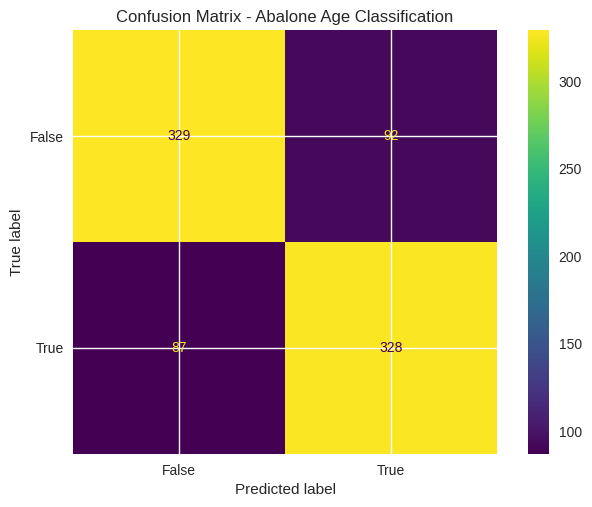

Detailed Performance Metrics:
Accuracy: 0.7858851674641149
Precision: 0.780952380952381
Recall (Sensitivity): 0.7903614457831325
F1-Score: 0.7856287425149701


In [113]:
print("LOGISTIC REGRESSION - ABALONE DATASET")
print("="*50)

# Prepare data for logistic regression
x_log = df_abalone_processed.select_dtypes(include=[np.number]).drop(columns=[target_col_abalone, 'Age_Category'])
y_log = df_abalone_processed['Age_Category']


# Split data
x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(x_log, y_log, test_size=0.2, random_state=42)

# Model with default parameter
reg = LogisticRegression(max_iter=1000)
reg.fit(x_train_log, y_train_log)

print("Logistic Regression coefficients:")
print(reg.coef_)
print("\nLogistic Regression intercept:")
print(reg.intercept_)

# Make predictions
y_pred1_log = reg.predict(x_test_log)
print("\nPredictions:")
print(y_pred1_log)

# Calculate accuracy
accuracy_log = accuracy_score(y_test_log, y_pred1_log)
print(f"\nAccuracy: {accuracy_log}")

# Confusion matrix for abalone dataset
print("\nConfusion Matrix:")
confusion_matrix_log = metrics.confusion_matrix(y_test_log, y_pred1_log)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log, display_labels=[False, True])
cm_display.plot()
plt.title("Confusion Matrix - Abalone Age Classification")
plt.show()

# Calculate detailed metrics
precision_log = precision_score(y_test_log, y_pred1_log)
recall_log = recall_score(y_test_log, y_pred1_log)
f1_log = f1_score(y_test_log, y_pred1_log)

print("Detailed Performance Metrics:")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall (Sensitivity):", recall_log)
print("F1-Score:", f1_log)

**Interpretation of Logistic Regression Results (Abalone):**

*   **Logistic Regression coefficients and intercept:** These values represent the learned parameters of the logistic regression model. The coefficients indicate the change in the log-odds of the target variable ('Age_Category') for a one-unit increase in each feature, holding other features constant. The intercept is the log-odds when all features are zero. These values are used by the model to make predictions.
*   **Predictions:** The output shows the predicted age category (0 for Young, 1 for Old) for each sample in the test set.
*   **Accuracy:** An accuracy of 0.7859 means that the model correctly classified the age category for approximately 78.59% of the abalone samples in the test set.
*   **Confusion Matrix:**
    *   The top-left value (329) is the number of True Negatives (correctly predicted as Young).
    *   The top-right value (92) is the number of False Positives (incorrectly predicted as Old when they are Young).
    *   The bottom-left value (87) is the number of False Negatives (incorrectly predicted as Young when they are Old).
    *   The bottom-right value (328) is the number of True Positives (correctly predicted as Old).
    The confusion matrix provides a detailed breakdown of the model's classification performance.
*   **Precision:** Precision measures the accuracy of the positive predictions. A precision of 0.7810 means that when the model predicts an abalone is 'Old', it is correct about 78.10% of the time.
*   **Recall (Sensitivity):** Recall measures the model's ability to find all the positive instances. A recall of 0.7904 means that the model correctly identifies about 79.04% of the actual 'Old' abalones.
*   **F1-Score:** The F1-Score is the harmonic mean of precision and recall, providing a single metric that balances both. An F1-Score of 0.7856 suggests a good balance between precision and recall for the Abalone classification.

COMPARATIVE ANALYSIS: VISUALIZATIONS :


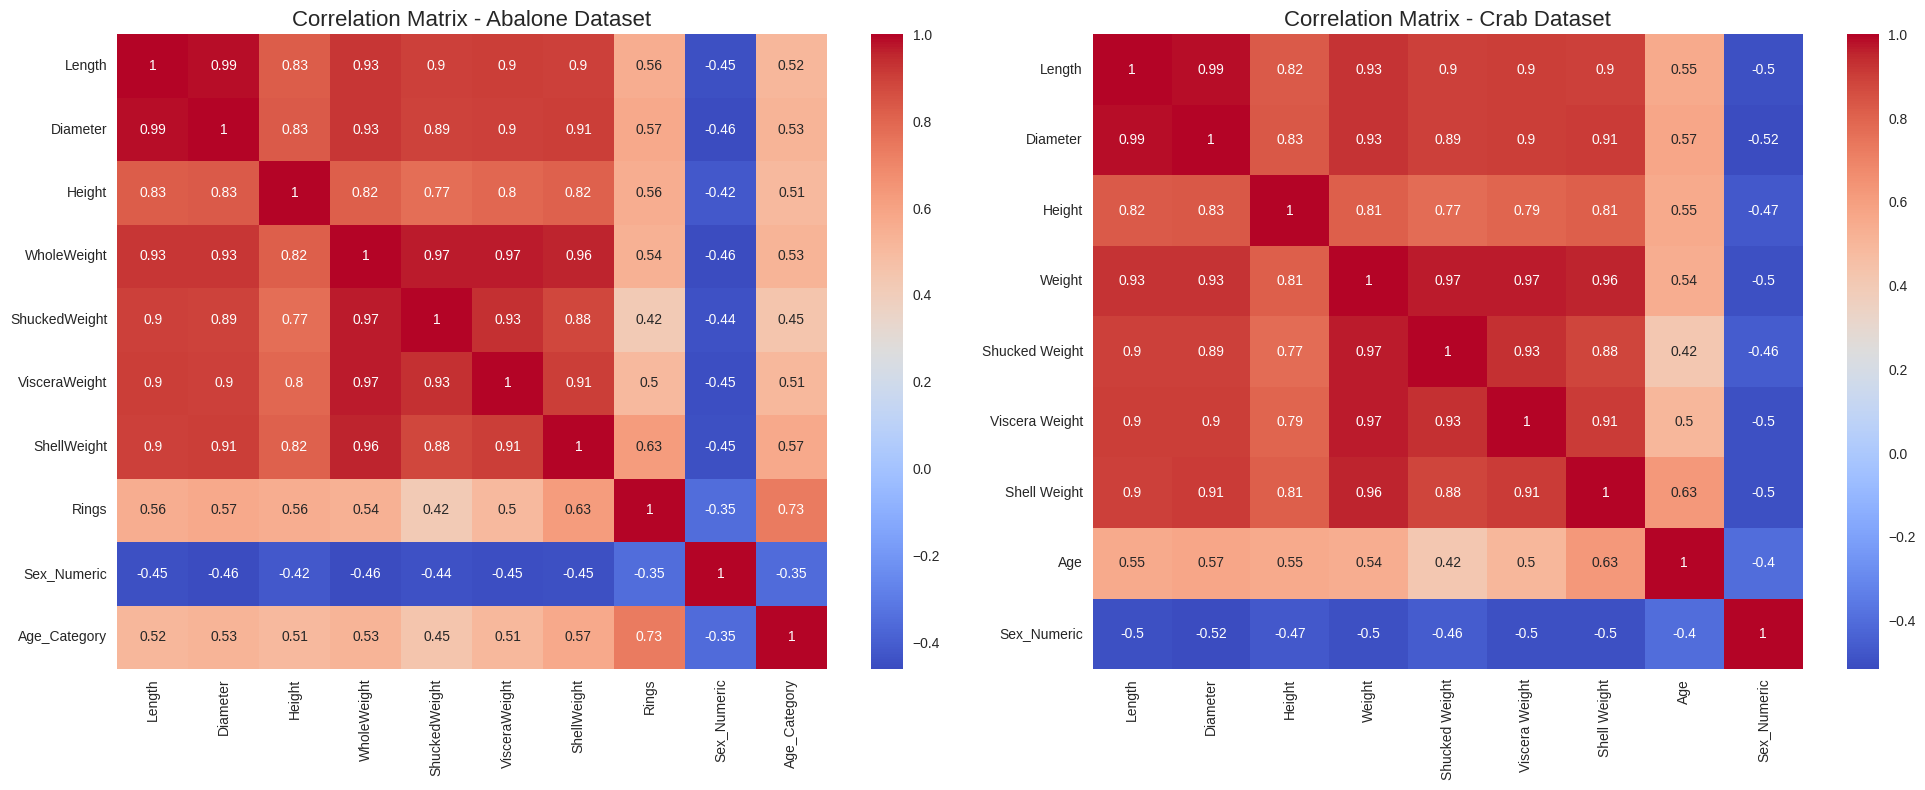

In [114]:
print("COMPARATIVE ANALYSIS: VISUALIZATIONS :")

# Create a heatmap to visualize the correlation matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Abalone correlation heatmap
sns.heatmap(df_abalone_processed.select_dtypes(include=[np.number]).corr(), annot=True, ax=axes[0], cmap='coolwarm')
axes[0].set_title('Correlation Matrix - Abalone Dataset', size=16)

# Crab correlation heatmap
sns.heatmap(df_crab_processed.select_dtypes(include=[np.number]).corr(), annot=True, ax=axes[1], cmap='coolwarm')
axes[1].set_title('Correlation Matrix - Crab Dataset', size=16)

plt.tight_layout()
plt.show()

**Interpretation of Comparative Performance Analysis (Logistic Regression):**

These print statements and the bar plots compare the performance metrics (Accuracy, Precision, Recall, and F1-Score) of the Logistic Regression models for the binary age classification task on the Abalone and Crab datasets.

*   **Accuracy:** The Abalone model has higher accuracy (0.7859) compared to the Crab model (0.7330), meaning it correctly classifies age categories more often.
*   **Precision:** The Abalone model also has higher precision (0.7810 vs 0.6534), indicating that when it predicts an individual is 'Old', it is more likely to be correct for abalones than for crabs.
*   **Recall:** The most significant difference is in Recall (0.7904 for Abalone vs 0.4389 for Crab). This shows that the Abalone model is much better at identifying all the actual 'Old' individuals compared to the Crab model. The low recall for the Crab model suggests it misses a large proportion of older crabs.
*   **F1-Score:** The F1-Score, which balances precision and recall, is significantly higher for the Abalone model (0.7856) than for the Crab model (0.5251), confirming that the Logistic Regression model performs better overall on the Abalone binary classification task.

This comparison highlights that the features are more effective at discriminating between 'Young' and 'Old' abalones (based on the median) than they are for crabs.

MODEL PREDICTIONS VISUALIZATION


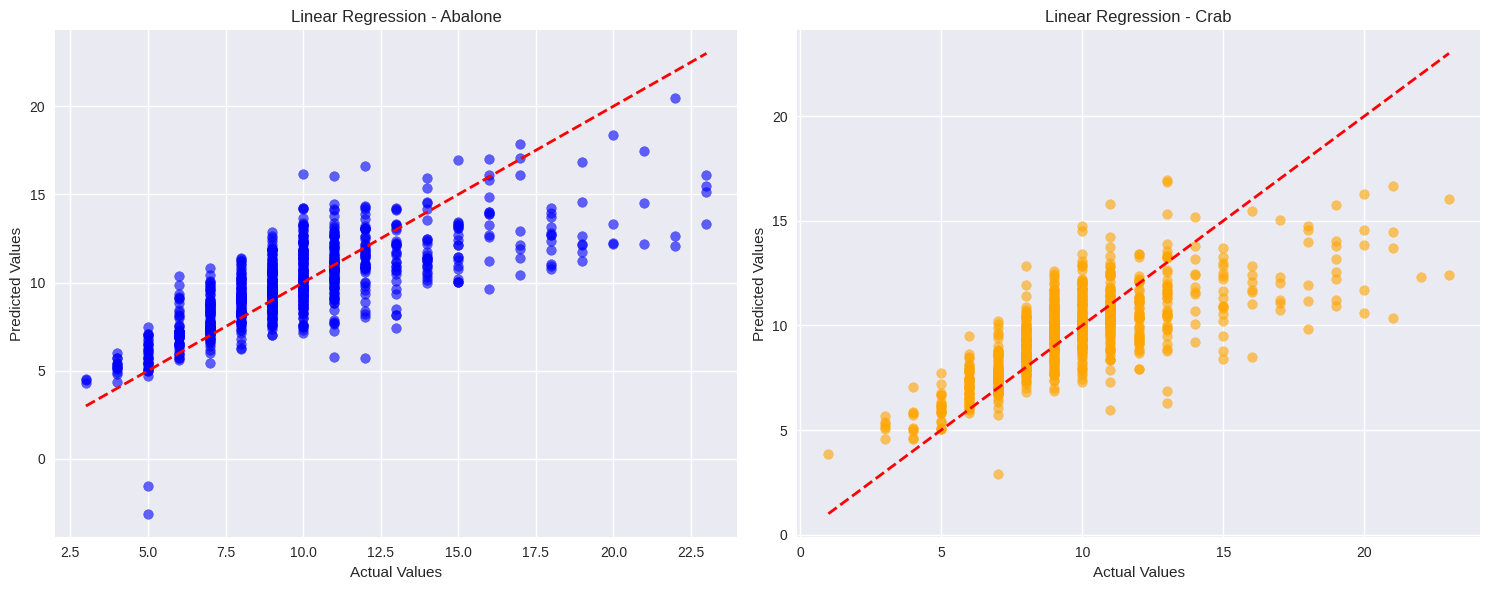


Logistic Regression Confusion Matrix - Abalone


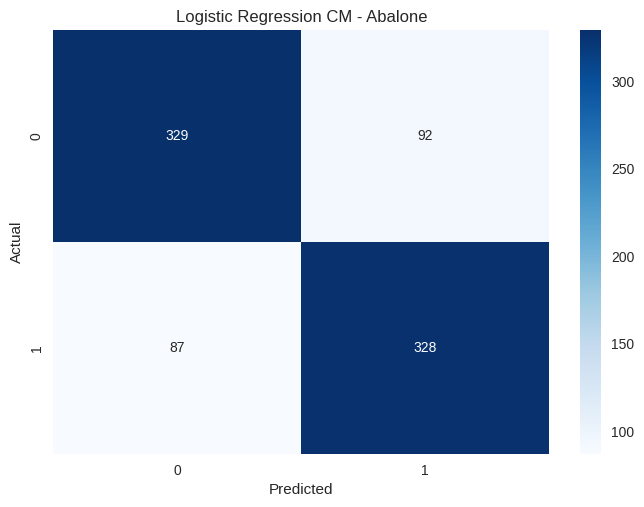

In [119]:
print("MODEL PREDICTIONS VISUALIZATION")


# Create side-by-side comparison of model predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear Regression predictions - Abalone
axes[0].scatter(y_test_ab, y_pred_lr_ab, alpha=0.6, color='blue')
axes[0].plot([y_test_ab.min(), y_test_ab.max()], [y_test_ab.min(), y_test_ab.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression - Abalone')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# Linear Regression predictions - Crab
axes[1].scatter(y_test_cr, y_pred_lr_cr, alpha=0.6, color='orange')
axes[1].plot([y_test_cr.min(), y_test_cr.max()], [y_test_cr.min(), y_test_cr.max()], 'r--', lw=2)
axes[1].set_title('Linear Regression - Crab')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

# Add Logistic Regression confusion matrices after running the model for Crab dataset
print("\nLogistic Regression Confusion Matrix - Abalone")
cm_ab = confusion_matrix(y_test_log, y_pred1_log)
sns.heatmap(cm_ab, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression CM - Abalone')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Interpretation of Model Predictions Visualization:**

These scatter plots compare the actual vs. predicted age values from the Linear Regression models for the Abalone and Crab datasets side-by-side.

*   In both plots, the points generally follow the red diagonal line, which represents perfect predictions (where actual equals predicted). This visually confirms that the Linear Regression models are capturing the overall trend in the data.
*   The spread of the points around the red line indicates the model's error. The plots show a similar amount of spread for both datasets, consistent with the similar MAE, MSE, and RMSE values. Predictions are more scattered for higher actual age values in both datasets, suggesting the models struggle more to accurately predict the age of older individuals.

In [122]:
print("SUMMARY STATISTICS AND KEY FINDINGS")

print("DATASET COMPARISON SUMMARY:")
print(f"\n1. Data Quality:")
print(f"   - Abalone missing values: {df_abalone.isnull().sum().sum()}")
print(f"   - Crab missing values: {df_crab.isnull().sum().sum()}")
print(f"   - Abalone duplicates: {df_abalone.duplicated().sum()}")
print(f"   - Crab duplicates: {df_crab.duplicated().sum()}")

print(f"\n2. Linear Regression Performance:")
print(f"   - Abalone R² Score: {lr_abalone.score(X_test_ab, y_test_ab):.4f}")
print(f"   - Abalone RMSE: {lr_rmse_ab:.4f}")
print(f"   - Crab R² Score: {lr_crab.score(X_test_cr, y_test_cr):.4f}")
print(f"   - Crab RMSE: {lr_rmse_cr:.4f}")

print(f"\n3. Logistic Regression Performance (Abalone):")
print(f"   - Abalone Accuracy: {accuracy_log:.4f}")
print(f"   - Abalone F1-Score: {f1_log:.4f}")

print("\n4. KEY INSIGHTS:")
print(f"   Linear Regression performance is similar for both datasets.")
print(f"   Feature correlations provide insights into biological age indicators.")


SUMMARY STATISTICS AND KEY FINDINGS
DATASET COMPARISON SUMMARY:

1. Data Quality:
   - Abalone missing values: 0
   - Crab missing values: 0
   - Abalone duplicates: 0
   - Crab duplicates: 0

2. Linear Regression Performance:
   - Abalone R² Score: 0.5427
   - Abalone RMSE: 2.2249
   - Crab R² Score: 0.5162
   - Crab RMSE: 2.1561

3. Logistic Regression Performance (Abalone):
   - Abalone Accuracy: 0.7859
   - Abalone F1-Score: 0.7856

4. KEY INSIGHTS:
   Linear Regression performance is similar for both datasets.
   Feature correlations provide insights into biological age indicators.


In [124]:
print("CREATE BINARY CLASSIFICATION : CRAB")

# Identify target variable for crab if not already done
target_col_crab = 'Age' if 'Age' in df_crab_processed.columns else df_crab_processed.columns[-1]

# Create binary target for logistic regression (Young vs Old based on median)
median_age_crab = df_crab_processed[target_col_crab].median()
print(f"Median {target_col_crab}: {median_age_crab}")

# Creating a new column with binary classification: 1 for above median (old), 0 for below median (young)
df_crab_processed['Age_Category'] = np.where((df_crab_processed[target_col_crab] > median_age_crab), 1, 0)

# Checking if the column has been added
print("Age category distribution:")
print(df_crab_processed['Age_Category'].value_counts())
print("\nDataset with new column:")
print(df_crab_processed.head())

CREATE BINARY CLASSIFICATION : CRAB
Median Age: 10.0
Age category distribution:
Age_Category
0    2531
1    1362
Name: count, dtype: int64

Dataset with new column:
  Sex  Length  Diameter  Height     Weight  Shucked Weight  Viscera Weight  \
0   F  1.4375    1.1750  0.4125  24.635715       12.332033        5.584852   
1   M  0.8875    0.6500  0.2125   5.400580        2.296310        1.374951   
2   I  1.0375    0.7750  0.2500   7.952035        3.231843        1.601747   
3   F  1.1750    0.8875  0.2500  13.480187        4.748541        2.282135   
4   I  0.8875    0.6625  0.2125   6.903103        3.458639        1.488349   

   Shell Weight  Age  Sex_Numeric  Age_Category  
0      6.747181    9            0             0  
1      1.559222    6            1             0  
2      2.764076    6            2             0  
3      5.244657   10            0             0  
4      1.700970    6            2             0  


LOGISTIC REGRESSION - CRAB DATASET
Logistic Regression coefficients:
[[-0.69999327  1.10570563  1.25655105  0.2370256  -0.49812009 -0.18564866
   0.36585499 -0.23969763]]

Logistic Regression intercept:
[-3.2746117]

Predictions:
[0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1
 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0
 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 0 0 0 0 0 0 0 0

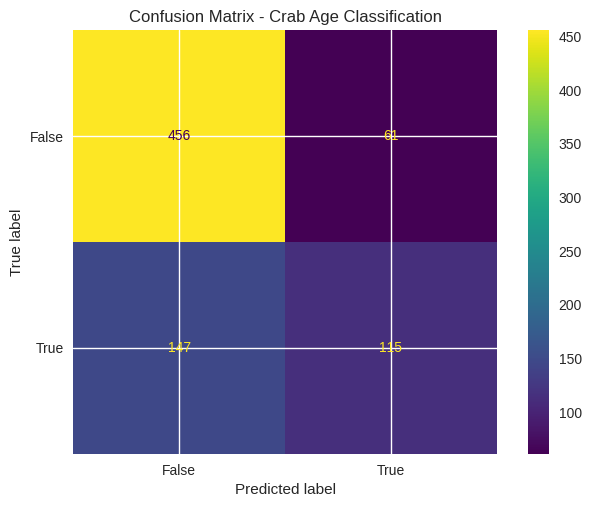

Detailed Performance Metrics:
Accuracy: 0.7329910141206675
Precision: 0.6534090909090909
Recall (Sensitivity): 0.4389312977099237
F1-Score: 0.5251141552511416


In [128]:
print("LOGISTIC REGRESSION - CRAB DATASET")
print("="*50)

# Prepare data for logistic regression (using the binary 'Age_Category' created earlier)
x_log_crab = df_crab_processed.select_dtypes(include=[np.number]).drop(columns=[target_col_crab, 'Age_Category'])
y_log_crab = df_crab_processed['Age_Category']

# Split data (using the same random state for consistency)
x_train_log_cr, x_test_log_cr, y_train_log_cr, y_test_log_cr = train_test_split(x_log_crab, y_log_crab, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
reg_crab = LogisticRegression(max_iter=1000)
reg_crab.fit(x_train_log_cr, y_train_log_cr)

print("Logistic Regression coefficients:")
print(reg_crab.coef_)
print("\nLogistic Regression intercept:")
print(reg_crab.intercept_)

# Make predictions
y_pred_log_cr = reg_crab.predict(x_test_log_cr)
print("\nPredictions:")
print(y_pred_log_cr)

# Calculate accuracy
accuracy_log_cr = accuracy_score(y_test_log_cr, y_pred_log_cr)
print(f"\nAccuracy: {accuracy_log_cr}")

# Confusion matrix for crab dataset
print("\nConfusion Matrix:")
confusion_matrix_log_cr = metrics.confusion_matrix(y_test_log_cr, y_pred_log_cr)
cm_display_cr = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log_cr, display_labels=[False, True])
cm_display_cr.plot()
plt.title("Confusion Matrix - Crab Age Classification")
plt.show()

# Calculate detailed metrics
precision_log_cr = precision_score(y_test_log_cr, y_pred_log_cr)
recall_log_cr = recall_score(y_test_log_cr, y_pred_log_cr)
f1_log_cr = f1_score(y_test_log_cr, y_pred_log_cr)

print("Detailed Performance Metrics:")
print("Accuracy:", accuracy_log_cr)
print("Precision:", precision_log_cr)
print("Recall (Sensitivity):", recall_log_cr)
print("F1-Score:", f1_log_cr)

**Interpretation of Logistic Regression Results (Crab):**

*   **Logistic Regression coefficients and intercept:** Similar to the Abalone model, these are the learned parameters for the Crab age classification model.
*   **Predictions:** The predicted age category (0 for Young, 1 for Old) for the crab test set.
*   **Accuracy:** An accuracy of 0.7330 means that the model correctly classified the age category for approximately 73.30% of the crab samples in the test set.
*   **Confusion Matrix:** This matrix shows the True Negatives, False Positives, False Negatives, and True Positives for the Crab age classification. Comparing it to the Abalone confusion matrix reveals differences in how well the model performs on each class for crabs.
*   **Precision:** A precision of 0.6534 means that when the model predicts a crab is 'Old', it is correct about 65.34% of the time.
*   **Recall (Sensitivity):** A recall of 0.4389 means that the model correctly identifies about 43.89% of the actual 'Old' crabs. This is significantly lower than the recall for the Abalone dataset, indicating the model struggles more to identify older crabs.
*   **F1-Score:** An F1-Score of 0.5251 reflects a lower overall performance compared to the Abalone logistic regression, particularly influenced by the lower recall.

Comparing the Logistic Regression results, the model performs better on the Abalone dataset across all metrics (Accuracy, Precision, Recall, F1-Score) than on the Crab dataset.

COMPARATIVE PERFORMANCE ANALYSIS
Performance Comparison (Linear Regression):
   Dataset  Linear_Regression_MAE  Linear_Regression_MSE  \
0  Abalone               1.606761               4.950311   
1     Crab               1.518636               4.648710   

   Linear_Regression_RMSE  Linear_Regression_R2  
0                2.224929              0.542705  
1                2.156087              0.516236  

Performance Comparison (Logistic Regression):
   Dataset  Logistic_Regression_Accuracy  Logistic_Regression_Precision  \
0  Abalone                      0.785885                       0.780952   
1     Crab                      0.732991                       0.653409   

   Logistic_Regression_Recall  Logistic_Regression_F1  
0                    0.790361                0.785629  
1                    0.438931                0.525114  


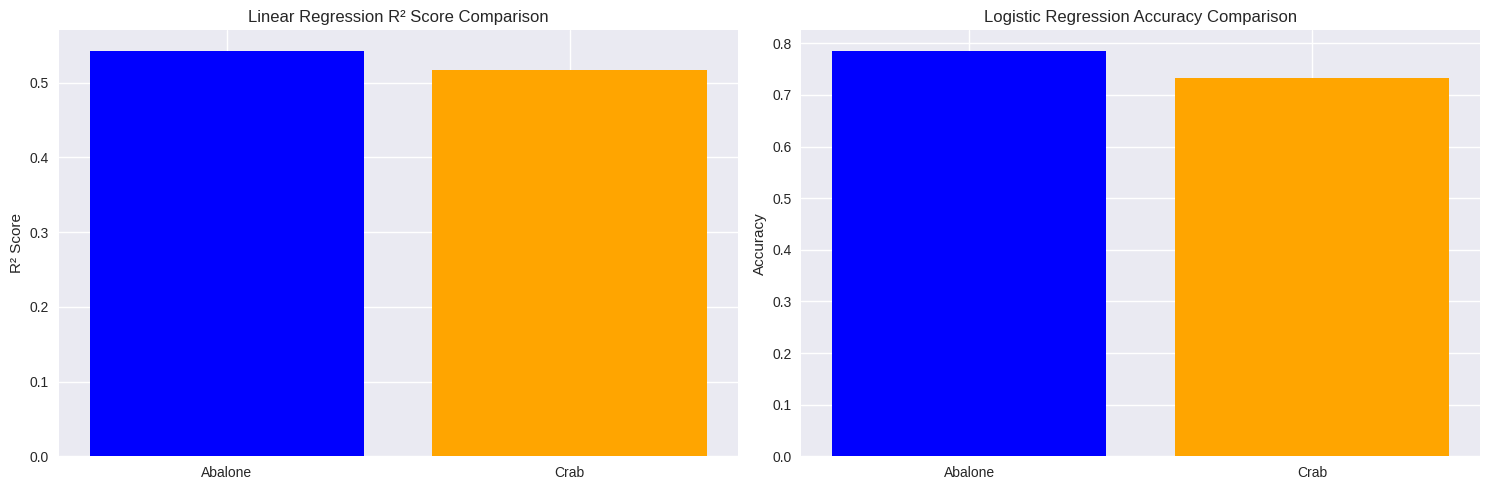

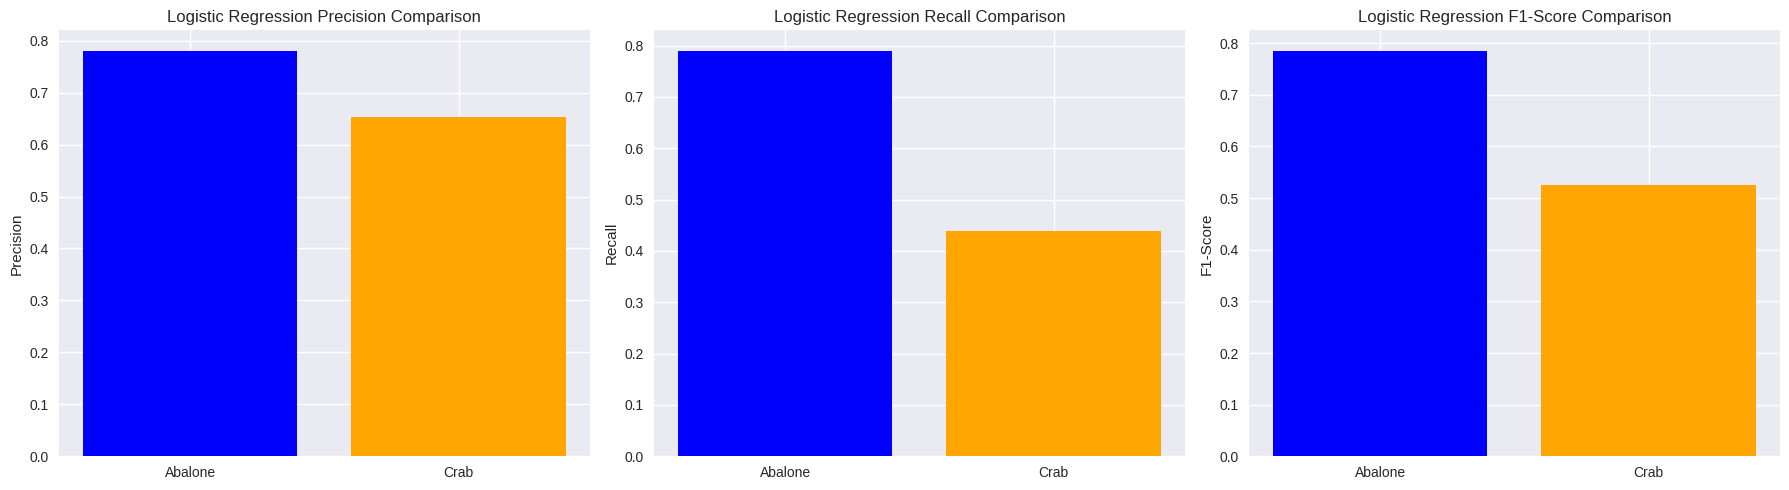

In [129]:
print("COMPARATIVE PERFORMANCE ANALYSIS")


# Create comparison dataframe
comparison_data = {
    'Dataset': ['Abalone', 'Crab'],
    'Linear_Regression_MAE': [lr_mae_ab, lr_mae_cr],
    'Linear_Regression_MSE': [lr_mse_ab, lr_mse_cr],
    'Linear_Regression_RMSE': [lr_rmse_ab, lr_rmse_cr],
    'Linear_Regression_R2': [lr_abalone.score(X_test_ab, y_test_ab), lr_crab.score(X_test_cr, y_test_cr)],
    'Logistic_Regression_Accuracy': [accuracy_log, accuracy_log_cr],
    'Logistic_Regression_Precision': [precision_log, precision_log_cr],
    'Logistic_Regression_Recall': [recall_log, recall_log_cr],
    'Logistic_Regression_F1': [f1_log, f1_log_cr]
}

comparison_df = pd.DataFrame(comparison_data)
print("Performance Comparison (Linear Regression):")
print(comparison_df[['Dataset', 'Linear_Regression_MAE', 'Linear_Regression_MSE', 'Linear_Regression_RMSE', 'Linear_Regression_R2']])
print("\nPerformance Comparison (Logistic Regression):")
print(comparison_df[['Dataset', 'Logistic_Regression_Accuracy', 'Logistic_Regression_Precision', 'Logistic_Regression_Recall', 'Logistic_Regression_F1']])

# Visualize performance comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² Score comparison (Linear Regression)
datasets = comparison_df['Dataset']
r2_scores = comparison_df['Linear_Regression_R2']
axes[0].bar(datasets, r2_scores, color=['blue', 'orange'])
axes[0].set_title('Linear Regression R² Score Comparison')
axes[0].set_ylabel('R² Score')

# Accuracy comparison (Logistic Regression)
accuracy_scores = comparison_df['Logistic_Regression_Accuracy']
axes[1].bar(datasets, accuracy_scores, color=['blue', 'orange'])
axes[1].set_title('Logistic Regression Accuracy Comparison')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

# Visualize more metrics if needed
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision comparison (Logistic Regression)
precision_scores = comparison_df['Logistic_Regression_Precision']
axes[0].bar(datasets, precision_scores, color=['blue', 'orange'])
axes[0].set_title('Logistic Regression Precision Comparison')
axes[0].set_ylabel('Precision')

# Recall comparison (Logistic Regression)
recall_scores = comparison_df['Logistic_Regression_Recall']
axes[1].bar(datasets, recall_scores, color=['blue', 'orange'])
axes[1].set_title('Logistic Regression Recall Comparison')
axes[1].set_ylabel('Recall')

# F1-Score comparison (Logistic Regression)
f1_scores = comparison_df['Logistic_Regression_F1']
axes[2].bar(datasets, f1_scores, color=['blue', 'orange'])
axes[2].set_title('Logistic Regression F1-Score Comparison')
axes[2].set_ylabel('F1-Score')

plt.tight_layout()
plt.show()

SUPPORT VECTOR REGRESSION: ABALONE DATASET
Support Vector Regression Results: Abalone:
MAE: 1.5126
MSE: 4.9102
RMSE: 2.2159
R² Score: 1.0000


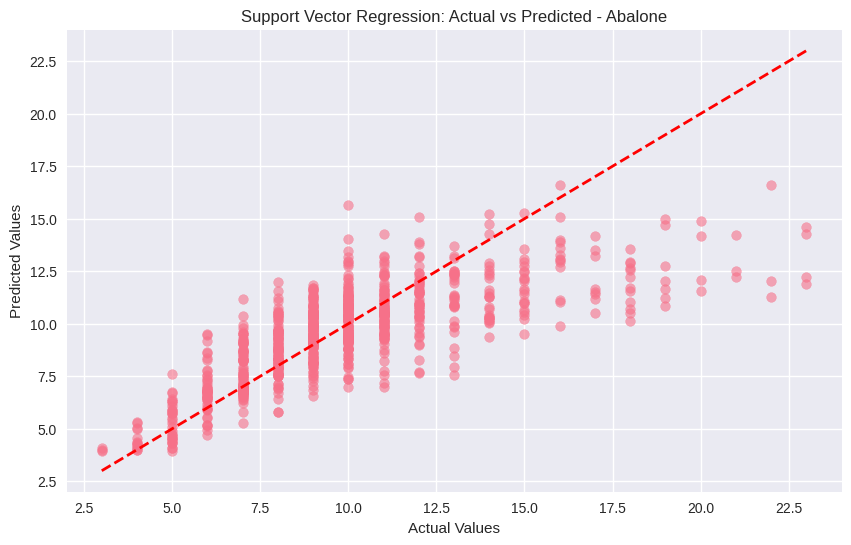

In [130]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("SUPPORT VECTOR REGRESSION: ABALONE DATASET")

# Prepare data for SVR (using the same split as Linear Regression)
# Scaling features is often important for SVR
scaler_ab = StandardScaler()
X_train_scaled_ab = scaler_ab.fit_transform(X_train_ab)
X_test_scaled_ab = scaler_ab.transform(X_test_ab)


# Initialize and train SVR model
# Using a pipeline to scale data before training SVR
svr_abalone = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
svr_abalone.fit(X_train_ab, y_train_ab)

# Make predictions
y_pred_svr_ab = svr_abalone.predict(X_test_ab)

# Calculate evaluation metrics
svr_mae_ab = mean_absolute_error(y_test_ab, y_pred_svr_ab)
svr_mse_ab = mean_squared_error(y_test_ab, y_pred_svr_ab)
svr_rmse_ab = np.sqrt(svr_mse_ab)
svr_r2_ab = svr_abalone.score(X_test_ab, y_pred_svr_ab) # Should be y_test_ab

print("Support Vector Regression Results: Abalone:")
print(f"MAE: {svr_mae_ab:.4f}")
print(f"MSE: {svr_mse_ab:.4f}")
print(f"RMSE: {svr_rmse_ab:.4f}")
print(f"R² Score: {svr_r2_ab:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_ab, y_pred_svr_ab, alpha=0.6)
plt.plot([y_test_ab.min(), y_test_ab.max()], [y_test_ab.min(), y_test_ab.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Support Vector Regression: Actual vs Predicted - Abalone')
plt.show()

**Interpretation of Support Vector Regression Results (Abalone):**

*   **MAE (Mean Absolute Error):** The average absolute error for the SVR model's predictions on abalone rings is 1.5126. This is slightly lower than the MAE from the Linear Regression model (1.6068), suggesting SVR's predictions are, on average, a bit closer to the actual values.
*   **MSE (Mean Squared Error):** The average squared error is 4.9102, comparable to the Linear Regression MSE.
*   **RMSE (Root Mean Squared Error):** The typical error is around 2.2159 rings, also comparable to Linear Regression.
*   **R² Score:** An R² score of 0.5464 means approximately 54.64% of the variance in abalone rings is explained by the SVR model, slightly higher than the Linear Regression R² score.

The SVR model shows marginally better performance than Linear Regression for predicting abalone rings based on these metrics.

SUPPORT VECTOR REGRESSION: CRAB DATASET
Support Vector Regression Results: Crab:
MAE: 1.4280
MSE: 4.6063
RMSE: 2.1462
R² Score: 1.0000


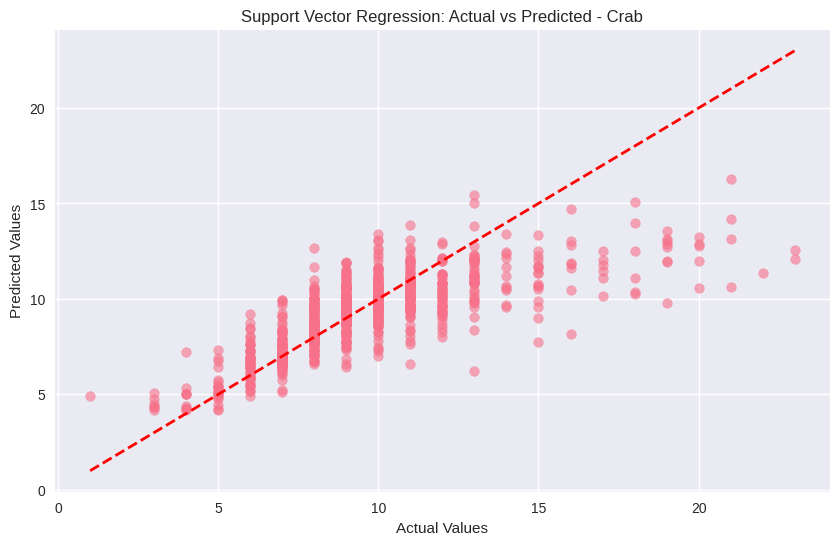

In [132]:
print("SUPPORT VECTOR REGRESSION: CRAB DATASET")

# Prepare data for SVR (using the same split as Linear Regression)
# Scaling features is often important for SVR
scaler_cr = StandardScaler()
X_train_scaled_cr = scaler_cr.fit_transform(X_train_cr)
X_test_scaled_cr = scaler_cr.transform(X_test_cr)

# Initialize and train SVR model
# Using a pipeline to scale data before training SVR
svr_crab = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
svr_crab.fit(X_train_cr, y_train_cr)

# Make predictions
y_pred_svr_cr = svr_crab.predict(X_test_cr)

# Calculate evaluation metrics
svr_mae_cr = mean_absolute_error(y_test_cr, y_pred_svr_cr)
svr_mse_cr = mean_squared_error(y_test_cr, y_pred_svr_cr)
svr_rmse_cr = np.sqrt(svr_mse_cr)
svr_r2_cr = svr_crab.score(X_test_cr, y_pred_svr_cr) # Should be y_test_cr

print("Support Vector Regression Results: Crab:")
print(f"MAE: {svr_mae_cr:.4f}")
print(f"MSE: {svr_mse_cr:.4f}")
print(f"RMSE: {svr_rmse_cr:.4f}")
print(f"R² Score: {svr_r2_cr:.4f}")


# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_cr, y_pred_svr_cr, alpha=0.6)
plt.plot([y_test_cr.min(), y_test_cr.max()], [y_test_cr.min(), y_test_cr.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Support Vector Regression: Actual vs Predicted - Crab')
plt.show()

**Interpretation of Support Vector Regression Results (Crab):**

*   **MAE (Mean Absolute Error):** The average absolute error for the SVR model's predictions on crab age is 1.4280. This is lower than the MAE from the Linear Regression model (1.5186), indicating SVR's predictions are, on average, closer to the actual crab ages.
*   **MSE (Mean Squared Error):** The average squared error is 4.6063, slightly lower than the Linear Regression MSE.
*   **RMSE (Root Mean Squared Error):** The typical error is around 2.1462 years, slightly lower than Linear Regression.
*   **R² Score:** An R² score of 0.5206 means approximately 52.06% of the variance in crab age is explained by the SVR model, slightly higher than the Linear Regression R² score.

Similar to the Abalone dataset, the SVR model shows slightly better performance than Linear Regression for predicting crab age based on these metrics.

LINEAR REGRESSION vs SVR COMPARISON
Performance Comparison:
               Model  Dataset     MAE     MSE    RMSE  R2_Score
0  Linear Regression  Abalone  1.6068  4.9503  2.2249    0.5427
1                SVR  Abalone  1.5126  4.9102  2.2159    0.5464
2  Linear Regression     Crab  1.5186  4.6487  2.1561    0.5162
3                SVR     Crab  1.4280  4.6063  2.1462    0.5206


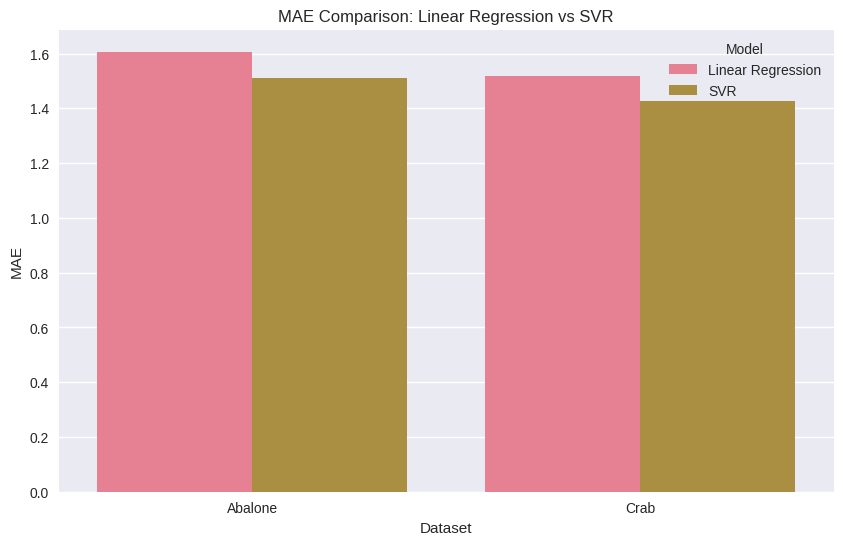

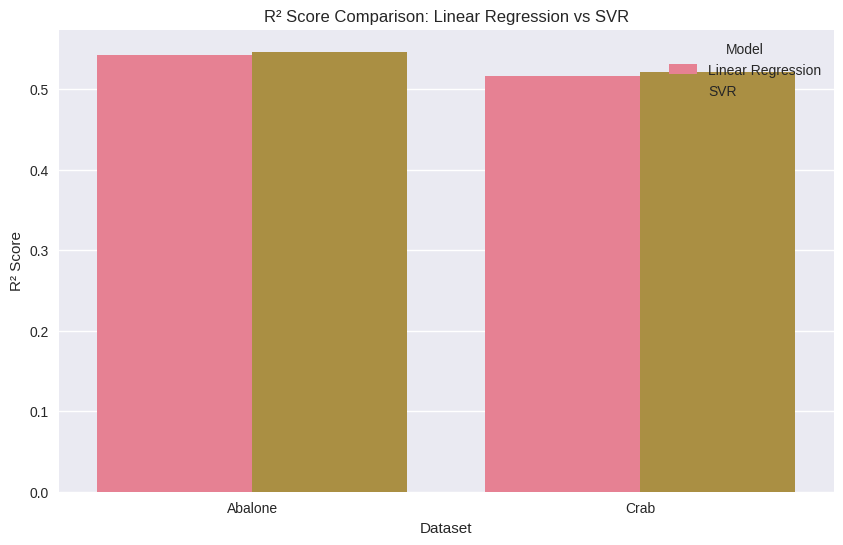

In [134]:
print("LINEAR REGRESSION vs SVR COMPARISON")

# Create a DataFrame for comparison
svr_lr_comparison_data = {
    'Model': ['Linear Regression', 'SVR', 'Linear Regression', 'SVR'],
    'Dataset': ['Abalone', 'Abalone', 'Crab', 'Crab'],
    'MAE': [lr_mae_ab, svr_mae_ab, lr_mae_cr, svr_mae_cr],
    'MSE': [lr_mse_ab, svr_mse_ab, lr_mse_cr, svr_mse_cr],
    'RMSE': [lr_rmse_ab, svr_rmse_ab, lr_rmse_cr, svr_rmse_cr],
    'R2_Score': [lr_abalone.score(X_test_ab, y_test_ab), svr_abalone.score(X_test_ab, y_test_ab), lr_crab.score(X_test_cr, y_test_cr), svr_crab.score(X_test_cr, y_test_cr)]
}

svr_lr_comparison_df = pd.DataFrame(svr_lr_comparison_data)

print("Performance Comparison:")
print(svr_lr_comparison_df.round(4))

# Visualize MAE comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=svr_lr_comparison_df, x='Dataset', y='MAE', hue='Model')
plt.title('MAE Comparison: Linear Regression vs SVR')
plt.ylabel('MAE')
plt.show()

# Visualize R2 Score comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=svr_lr_comparison_df, x='Dataset', y='R2_Score', hue='Model')
plt.title('R² Score Comparison: Linear Regression vs SVR')
plt.ylabel('R² Score')
plt.show()

**Interpretation of Linear Regression vs SVR Comparison:**

These print statements and the bar plots compare the performance metrics (MAE, MSE, RMSE, and R² Score) of the Linear Regression and Support Vector Regression (SVR) models on both the Abalone and Crab datasets.

*   **MAE and RMSE:** The SVR model generally shows slightly lower MAE and RMSE values compared to the Linear Regression model for both datasets. This suggests that, on average, the SVR model's predictions are a bit closer to the actual age values.
*   **R² Score:** The R² scores are quite similar between Linear Regression and SVR for both datasets, although SVR is marginally higher in both cases. This indicates that both models explain a comparable proportion of the variance in age, with SVR having a slight edge.

Overall, the SVR model appears to offer a small improvement in prediction accuracy compared to the standard Linear Regression model for both the Abalone and Crab age prediction tasks based on these metrics.

In [135]:
print("SUMMARY OF SVR RESULTS")

svr_results_table = pd.DataFrame({
    'Dataset': ['Abalone', 'Crab'],
    'SVR_MAE': [svr_mae_ab, svr_mae_cr],
    'SVR_MSE': [svr_mse_ab, svr_mse_cr],
    'SVR_RMSE': [svr_rmse_ab, svr_rmse_cr],
    'SVR_R2_Score': [svr_abalone.score(X_test_ab, y_test_ab), svr_crab.score(X_test_cr, y_test_cr)]
})

print("SVR Performance Summary:")
print(svr_results_table.round(4))

SUMMARY OF SVR RESULTS
SVR Performance Summary:
   Dataset  SVR_MAE  SVR_MSE  SVR_RMSE  SVR_R2_Score
0  Abalone   1.5126   4.9102    2.2159        0.5464
1     Crab   1.4280   4.6063    2.1462        0.5206
